# Noisy variational circuits — landscapes, plateaus, training and error mitigation

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

Every variational quantum algorithm written so far in this chapter assumed a perfect device. The circuit
$U(\boldsymbol\theta)$ was a product of exact unitaries, the state stayed pure, and the cost
$C(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert\hat H\vert\psi(\boldsymbol\theta)\rangle$ was the energy of
that pure state. Present-day hardware is not like that. A two-qubit gate on a superconducting processor fails a few
times in a thousand; qubits dephase while they wait; excited states decay. The circuit that runs is not
$U(\boldsymbol\theta)$ but a **quantum channel** $\mathcal E_{\boldsymbol\theta}$, and the state it produces is mixed.

This changes the optimisation problem itself as well as the accuracy of its answer. Three questions must be answered
before a variational algorithm can be trusted on a noisy device.

1. **What does noise do to the landscape?** If it only rescales the cost, the minimum is where it always was and the
   algorithm still finds the right state. If it deforms the cost, the algorithm optimises the wrong function.
2. **What does noise do to the gradients?** A landscape that flattens exponentially with circuit depth needs a number
   of measurements that grows exponentially with the depth before its gradients can be resolved, and a different
   optimiser does not change that.
3. **Can the damage be undone afterwards?** Error *correction* needs many more qubits than exist today; error
   *mitigation* trades extra circuit runs for a better estimate of the noiseless expectation value, and works now.

**Road map.**

* **Section 3** fixes the noise model — a channel after every rotation pair and on both qubits of every two-qubit
  gate — and derives the dictionary between the numbers a
  laboratory reports (average gate fidelity, $T_1$, $T_2$) and the channel parameters our simulator takes.
* **Section 4** builds the two simulators. The **density tensor** propagates $\rho$ exactly at cost $O(4^N)$; the
  **quantum trajectory** unravelling keeps a pure state at cost $O(2^N)$ per sample and converges as $1/\sqrt M$. They
  are checked against each other on the energy of a noisy variational state.
* **Section 5** derives how a Pauli expectation value contracts under local depolarising noise — a factor
  $(1-4p/3)$ per noisy qubit per layer — and measures the law where its assumptions hold exactly.
* **Section 6** proves that a **global** depolarising channel commutes with every unitary, so that
  $C_{\rm noisy}(\boldsymbol\theta)=(1-q)\,C(\boldsymbol\theta)+q\,\mathrm{Tr}\,\hat H/2^N$ and the minimiser is
  **unchanged**. Section 7 shows that **local** noise moves the minimiser: in closed form for one qubit under
  amplitude damping (non-unital) and under dephasing (unital), and for the four-qubit circuit under local
  depolarising, dephasing and damping noise through the gradient of the noisy cost at the noiseless optimum.
* **Section 8** measures **noise-induced barren plateaus**: the variance of a gradient component against circuit depth,
  with and without noise.
* **Sections 9 to 11** train under noise — exact gradients through the Kraus einsums against SPSA on trajectory
  estimates — test **optimal-parameter resilience** (train noisy, evaluate noiselessly) and measure the **depth
  trade-off** between expressivity and accumulated noise.
* **Section 12** implements **zero-noise extrapolation**, shows a regime where it removes most of the bias and one
  where it fails, and quantifies the price in measurement shots.
* **Section 13** measures the cost of both simulators against $N$ and locates the crossover.

### What you will learn

*Physics*

* how gate errors, dephasing and energy relaxation are represented as quantum channels, and how the channel parameters
  are read off from $T_1$, $T_2$ and a randomised-benchmarking error rate;
* why a global depolarising channel leaves the *position* of the variational minimum exactly where it was, while
  local channels, unital or not, shift it;
* why the useful circuit depth has an optimum that moves to smaller depth as the error rate grows;
* what error mitigation can and cannot do.

*Numerical methods*

* two representations of the same open-system dynamics, one deterministic and $O(4^N)$, one stochastic and $O(2^N)$,
  and how to validate either against the other with error bars and a deliberately wrong control;
* differentiating a channel: reverse-mode automatic differentiation straight through a chain of Kraus einsums;
* estimating a decay exponent from data and comparing it with a derived prediction;
* Richardson extrapolation of a noisy expectation value in the noise strength.

*Implementation practice*

* `lax.scan` over circuit layers so that the compiled graph does not grow with depth;
* `vmap` over noise strengths (the channel parameter is a traced number) and over random initialisations at the same
  time, so a whole two-dimensional sweep is one compiled program;
* keeping the *monitored* quantity exact while the *optimised* quantity is noisy.

### Prerequisites

* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  the density tensor, the Kraus form, the channel zoo, the stochastic unravelling;
* [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb):
  circuits as gate lists, `noisy_circuit_dm` and `noisy_circuit_mcwf`;
* [40 — parametrized gates and gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb):
  ansätze, cost functions, the parameter-shift rule, SPSA, barren plateaus in the noiseless case;
* [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb): Adam, SPSA with Spall gains, the
  `lax.scan` training loop and `vmap` over random starts;
* [42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb):
  the algorithm itself, which is taken as given here.

**Conventions and sizes.** The test problem throughout is the ground state of an XXZ chain in a transverse field on
$N=4$ qubits, with the hardware-efficient ansatz of notebook 40. Four qubits keep the density tensor at $4^4=256$
complex numbers, so exact gradients through the channel are cheap and every experiment can be repeated over many
random initialisations. The trajectory simulator is pushed to $N=12$ in the cost study of Section 13.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we need the two ways of acting on a density tensor (`apply_gate_dm`, `apply_kraus_dm`), the stochastic
unravelling (`apply_kraus_mcwf`), the three channels of the noise model, the ansatz and its parameter count, the
Hamiltonian term list and the exact ground state from Lanczos.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def expect_local_dm(rho, O, qubits):
    """Tr(rho O_qubits) for a density tensor, via its reduced density matrix."""
    return jnp.real(jnp.trace(rdm_dm(rho, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def expect_pauli_string_dm(rho, ops):
    """Tr(P rho): apply P to the KET axes only, then take the full trace."""
    return jnp.real(jnp.trace(dm_matrix(apply_pauli_string(rho, ops))))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) sigma^-)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi


In [3]:
# ==============================================================================
# PLOT STYLE + helpers reused from notebook 41 (training loop, statistics)
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def bands(hist):
    """Median and interquartile band of a batch of histories, shape (n_runs, n_steps) -> three curves."""
    h = np.asarray(hist)
    return np.percentile(h, 25, axis=0), np.median(h, axis=0), np.percentile(h, 75, axis=0)


def mean_and_se(x):
    """Sample mean and standard error of the mean of a 1D array of independent samples."""
    x = np.asarray(x)
    return float(np.mean(x)), float(np.std(x, ddof=1) / np.sqrt(x.size))


def opt_adam(lr, b1=0.9, b2=0.999, eps=1e-8):
    """Adam as a pair (init, update) of pure functions -- the optimiser interface of notebook 41."""
    def init(theta):
        return (jnp.zeros_like(theta), jnp.zeros_like(theta))

    def update(theta, state, g, k):
        m, v = state
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g ** 2
        return theta - lr * (m / (1 - b1 ** k)) / (jnp.sqrt(v / (1 - b2 ** k)) + eps), (m, v)

    return init, update


def train(theta0, key, grad_rule, opt, monitor, n_steps):
    """One training run compiled as a single `lax.scan` (notebook 41, Step 8).

    grad_rule(theta, key, k) -> gradient estimate;  opt = (init, update);  monitor(theta) -> recorded diagnostic.
    """
    init_fn, update_fn = opt

    def body(carry, k):
        theta, state, key = carry
        key, sub = jax.random.split(key)
        theta, state = update_fn(theta, state, grad_rule(theta, sub, k), k)
        return (theta, state, key), monitor(theta)

    (theta, _, _), hist = lax.scan(body, (theta0, init_fn(theta0), key), jnp.arange(1, n_steps + 1))
    return theta, hist


def random_starts(n_runs, n_params, seed, scale=jnp.pi):
    """`n_runs` independent parameter vectors drawn uniformly from [-scale, scale]^n, plus one PRNG key each."""
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    return (jax.random.uniform(k1, (n_runs, n_params), minval=-scale, maxval=scale),
            jax.random.split(k2, n_runs))


def timed(fn, *args, repeat=3):
    """Best of `repeat` wall-clock timings AFTER one warm-up call, so compilation is excluded."""
    jax.block_until_ready(fn(*args))
    ts = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        ts.append(time.perf_counter() - t0)
    return min(ts)


def compile_then_run(fn, *args):
    """Compile `jax.jit(fn)` for these argument shapes ahead of time, then run it once; time both phases separately.

    JAX   `jit(fn).lower(*args).compile()` traces and compiles without executing, so the second phase is pure run time.
    Returns (output, compile seconds, run seconds).
    """
    t0 = time.perf_counter()
    compiled = jax.jit(fn).lower(*args).compile()
    t1 = time.perf_counter()
    out = jax.block_until_ready(compiled(*args))
    return out, t1 - t0, time.perf_counter() - t1

## 3. The noise model and its parameters

### 3.1 A channel after every gate

The standard phenomenological model of a gate-based device is: **after a gate, every qubit the gate touched passes
through a single-qubit channel**. In this notebook the two rotations $R_y R_z$ on a qubit are treated as one
single-qubit gate followed by one channel, and both qubits of every two-qubit gate receive a channel. The channel is the
vehicle for two physically distinct effects.

* **Gate errors** — miscalibrated pulses, crosstalk, leakage — are modelled by a **depolarising** channel, because a
  randomised gate error looks isotropic on the Bloch sphere once averaged over the randomising circuits used to
  measure it. Two-qubit gates are an order of magnitude worse than single-qubit gates, so the model carries two error
  probabilities, $p_1$ and $p_2>p_1$.
* **Idling** — the qubit waiting while other gates are executed — is modelled by **dephasing** (loss of the relative
  phase, time constant $T_2$) and **amplitude damping** (decay $\vert1\rangle\to\vert0\rangle$, time constant $T_1$).

The three channels, with the Kraus operators the engine uses, are

$$\begin{aligned}
\mathcal D_p(\rho)&=(1-p)\,\rho+\frac p3\bigl(X\rho X+Y\rho Y+Z\rho Z\bigr), &&\text{depolarising},\\
\mathcal Z_p(\rho)&=(1-p)\,\rho+p\,Z\rho Z, &&\text{dephasing},\\
\mathcal A_\gamma(\rho)&=K_0\rho K_0^\dagger+K_1\rho K_1^\dagger,\quad
 K_0=\begin{pmatrix}1&0\\0&\sqrt{1-\gamma}\end{pmatrix},\ K_1=\begin{pmatrix}0&\sqrt\gamma\\0&0\end{pmatrix},
 &&\text{amplitude damping}.
\end{aligned}\tag{1}$$

### 3.2 Depolarising strength from an average gate fidelity

A laboratory does not publish $p$; it publishes an *error per gate* $r$ measured by randomised benchmarking, which is
$1-F_{\rm avg}$ with $F_{\rm avg}$ the gate fidelity averaged over input states. The dictionary follows from one
algebraic identity. For a single qubit,

$$\rho+X\rho X+Y\rho Y+Z\rho Z=2\,\mathrm{Tr}(\rho)\,\mathbb 1=2\cdot\mathbb 1,\tag{2}$$

which is checked by writing $\rho=\tfrac12(\mathbb 1+\mathbf r\cdot\boldsymbol\sigma)$ and using
$\sigma_a\sigma_b\sigma_a=-\sigma_b$ for $a\neq b$ and $\sigma_a\sigma_a\sigma_a=\sigma_a$: the three conjugations
flip the sign of two of the three Bloch components each, so
$\sum_a\sigma_a\rho\,\sigma_a=\tfrac12(3\cdot\mathbb 1-\mathbf r\cdot\boldsymbol\sigma)$, and adding $\rho$ gives
$2\cdot\mathbb 1$. Substituting Eq. (2) into the first line of Eq. (1),

$$\mathcal D_p(\rho)=\Bigl(1-\frac{4p}{3}\Bigr)\rho+\frac{4p}{3}\,\frac{\mathbb 1}{2}.\tag{3}$$

So the depolarising channel shrinks the Bloch vector by $\lambda\equiv1-4p/3$ and mixes in a fraction $4p/3$ of the
maximally mixed state. The fidelity of the output with the (pure) input is
$\langle\psi\vert\mathcal D_p(\vert\psi\rangle\langle\psi\vert)\vert\psi\rangle=\lambda+\tfrac{4p}{3}\cdot\tfrac12
=1-\tfrac{2p}{3}$, independently of $\vert\psi\rangle$. Hence

$$F_{\rm avg}=1-\frac{2p}{3},\qquad r=1-F_{\rm avg}=\frac{2p}{3},\qquad \boxed{\;p=\tfrac32\,r\;}.\tag{4}$$

A two-qubit gate needs one more step, because its error per gate is averaged over two-qubit inputs. The average
fidelity in dimension $d$ is fixed by the process fidelity $F_e=\sum_m\lvert\mathrm{Tr}K_m\rvert^2/d^2$ through
$F_{\rm avg}=(dF_e+1)/(d+1)$ (Nielsen 2002, in the references); for one qubit $F_e=1-p$ and this is Eq. (4) again. Our
model applies $\mathcal D_{p_2}$ to **both** qubits of the gate, so $F_e=(1-p_2)^2$ and, with $d=4$,
$r_2=\tfrac45\bigl[1-(1-p_2)^2\bigr]\simeq\tfrac85p_2$, i.e. $p_2\simeq\tfrac58r_2$ per qubit. Adding the two one-qubit
errors, $2\times\tfrac23p_2$, would undercount by a sixth. A two-qubit error per gate $r_2=5\cdot10^{-3}$ — a good
number on today's hardware — therefore corresponds to $p_2\approx3.1\cdot10^{-3}$ per qubit. We keep the simpler
convention $p_2=\tfrac32r_2$ per qubit and remember that the model's two-qubit gates are then pessimistic by a factor
$\tfrac85\cdot\tfrac32=2.4$.

### 3.3 Dephasing and damping from $T_1$ and $T_2$

Amplitude damping removes population from $\vert1\rangle$: from Eq. (1),
$\rho_{11}\to(1-\gamma)\rho_{11}$. Comparing with the exponential law $\rho_{11}(t)=e^{-t/T_1}\rho_{11}(0)$ for an
idling time $t$,

$$\gamma=1-e^{-t/T_1}.\tag{5}$$

Dephasing multiplies the coherence by $1-2p$, because $Z\rho Z$ flips the sign of $\rho_{01}$:
$\rho_{01}\to(1-p)\rho_{01}-p\rho_{01}$. Comparing with $\rho_{01}(t)=e^{-t/T_\varphi}\rho_{01}(0)$,

$$p=\tfrac12\bigl(1-e^{-t/T_\varphi}\bigr).\tag{6}$$

(The measured $T_2$ combines pure dephasing with the dephasing that damping itself produces,
$1/T_2=1/T_\varphi+1/(2T_1)$; Eq. (6) uses the pure-dephasing part.) Damping multiplies the coherence by
$\sqrt{1-\gamma}=e^{-t/(2T_1)}$, so the two channels together give

$$\lvert\rho_{01}(t)\rvert=\lvert\rho_{01}(0)\rvert\,e^{-t/(2T_1)}\,e^{-t/T_\varphi}=\lvert\rho_{01}(0)\rvert\,e^{-t/T_2}.\tag{6a}$$

Both laws are checked numerically below by applying the channels $n$ times and comparing with the exponentials.

depolarising p = 0.07
  Bloch vector in  : [ 0.6  0.4 -0.5]
  Bloch vector out : [ 0.544       0.36266667 -0.45333333]
  measured shrink factor 0.906666666667  vs 1-4p/3 = 0.906666666667


  average gate fidelity over the 6-state 2-design: 0.953333333333   vs 1-2p/3 = 0.953333333333
  error per gate r = 0.046667  ->  p = 3r/2 = 0.070000   (input was 0.07)

two-qubit gate, D_p on both qubits, p = 0.02: Haar average r = 0.03167 +- 0.00002
  (4/5)[1-(1-p)^2] = 0.03168   first order 8p/5 = 0.03200   naive 2 x 2p/3 = 0.02667



T1 = 20.0, T_phi = 12.0, step dt = 0.5  ->  gamma = 0.024690, p_dephase = 0.020405
  population  : max |measured - 0.5 exp(-t/T1)| = 1.11e-16
  coherence   : max |measured - 0.5 exp(-t/T2)| = 2.50e-16   (T2 = 9.2308 from Eq. 6a)


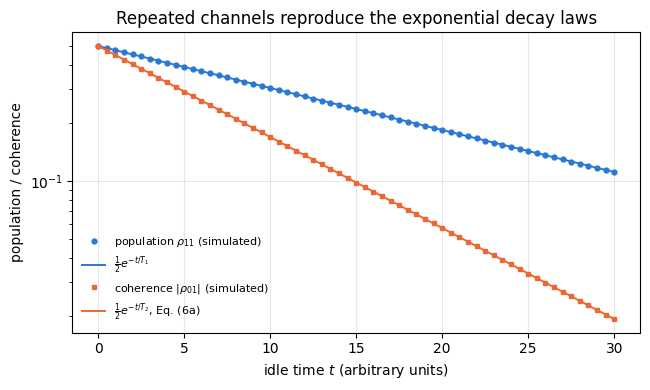

In [4]:
# ==============================================================================
# STEP 1: the noise-parameter dictionary, verified numerically
# ==============================================================================
# CHECK A: the depolarising channel contracts the Bloch vector by 1 - 4p/3 (Eq. 3)
p_chk = 0.07
rho_1q = 0.5 * (I2 + 0.6 * X + 0.4 * Y - 0.5 * Z)                     # an arbitrary mixed qubit
rho_out = apply_kraus_dm(rho_1q, kraus_depolarizing(p_chk), [0])
bloch_in = jnp.array([jnp.real(jnp.trace(rho_1q @ P)) for P in (X, Y, Z)])
bloch_out = jnp.array([jnp.real(jnp.trace(rho_out @ P)) for P in (X, Y, Z)])
lam_chk = 1 - 4 * p_chk / 3
print(f"depolarising p = {p_chk}")
print(f"  Bloch vector in  : {np.asarray(bloch_in)}")
print(f"  Bloch vector out : {np.asarray(bloch_out)}")
print(f"  measured shrink factor {float(bloch_out[0] / bloch_in[0]):.12f}  vs 1-4p/3 = {lam_chk:.12f}")
assert max_abs(bloch_out - lam_chk * bloch_in) < TOL

# CHECK B: the average gate fidelity of Eq. (4). The six +-X, +-Y, +-Z eigenstates form a 2-design, so
# averaging <psi|D_p(|psi><psi|)|psi> over them gives EXACTLY the Haar average.
six = [product_state(c) for c in ("0", "1", "+", "-", "r", "l")]
F_six = [float(jnp.real(jnp.vdot(psi, apply_kraus_dm(to_dm(psi), kraus_depolarizing(p_chk), [0]) @ psi)))
         for psi in six]                       # for N=1 the density TENSOR is already the 2x2 matrix
F_avg = float(np.mean(F_six))
print(f"  average gate fidelity over the 6-state 2-design: {F_avg:.12f}   vs 1-2p/3 = {1 - 2 * p_chk / 3:.12f}")
print(f"  error per gate r = {1 - F_avg:.6f}  ->  p = 3r/2 = {1.5 * (1 - F_avg):.6f}   (input was {p_chk})")
assert abs(F_avg - (1 - 2 * p_chk / 3)) < TOL

# CHECK B2: the two-qubit error per gate of the model (D_p on BOTH qubits), Haar-averaged over two-qubit inputs,
# against r = (4/5)[1 - (1-p)^2] from the process fidelity, and against the naive sum of two one-qubit errors 4p/3
p_pair = 0.02
K1_np = np.asarray(kraus_depolarizing(p_pair))
K_pair = [np.kron(a, b) for a in K1_np for b in K1_np]                 # Kraus operators of D_p (x) D_p
rng_pair = np.random.default_rng(0)
V = rng_pair.normal(size=(20000, 4)) + 1j * rng_pair.normal(size=(20000, 4))
V /= np.linalg.norm(V, axis=1, keepdims=True)                          # Haar-random two-qubit pure states
F_pair = sum(np.abs(np.einsum("ni,ij,nj->n", V.conj(), k, V)) ** 2 for k in K_pair)   # <psi|E(psi)|psi>
r_mc, r_se = 1 - F_pair.mean(), F_pair.std() / np.sqrt(len(F_pair))
r_formula = 0.8 * (1 - (1 - p_pair) ** 2)
print(f"\ntwo-qubit gate, D_p on both qubits, p = {p_pair}: Haar average r = {r_mc:.5f} +- {r_se:.5f}")
print(f"  (4/5)[1-(1-p)^2] = {r_formula:.5f}   first order 8p/5 = {1.6 * p_pair:.5f}   naive 2 x 2p/3 = {4 * p_pair / 3:.5f}")
assert abs(r_mc - r_formula) < 5 * r_se

# CHECK C: T1 and T2 laws, Eqs. (5) and (6)
T1, T2phi, dt, n_steps_T = 20.0, 12.0, 0.5, 60
gam_step = 1 - np.exp(-dt / T1)
p_step = 0.5 * (1 - np.exp(-dt / T2phi))
rho_T = to_dm(product_state("+"))                                     # |+> has both population and coherence
pop, coh = [], []
for n in range(n_steps_T + 1):
    m = dm_matrix(rho_T)
    pop.append(float(jnp.real(m[1, 1])))
    coh.append(float(jnp.abs(m[0, 1])))
    rho_T = apply_kraus_dm(rho_T, kraus_amplitude_damping(gam_step), [0])
    rho_T = apply_kraus_dm(rho_T, kraus_dephasing(p_step), [0])
t_axis = dt * np.arange(n_steps_T + 1)
pop_pred = 0.5 * np.exp(-t_axis / T1)
T2_eff = 1 / (1 / T2phi + 1 / (2 * T1))                              # Eq. (6a)
coh_pred = 0.5 * np.exp(-t_axis / T2_eff)
err_pop = np.max(np.abs(np.array(pop) - pop_pred))
err_coh = np.max(np.abs(np.array(coh) - coh_pred))
print(f"\nT1 = {T1}, T_phi = {T2phi}, step dt = {dt}  ->  gamma = {gam_step:.6f}, p_dephase = {p_step:.6f}")
print(f"  population  : max |measured - 0.5 exp(-t/T1)| = {err_pop:.2e}")
print(f"  coherence   : max |measured - 0.5 exp(-t/T2)| = {err_coh:.2e}   (T2 = {T2_eff:.4f} from Eq. 6a)")
assert err_pop < TOL and err_coh < TOL

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.semilogy(t_axis, pop, "o", ms=3.5, color=PALETTE[0], label=r"population $\rho_{11}$ (simulated)")
ax.semilogy(t_axis, pop_pred, "-", lw=1.4, color=PALETTE[0], label=r"$\frac{1}{2} e^{-t/T_1}$")
ax.semilogy(t_axis, coh, "s", ms=3.5, color=PALETTE[1], label=r"coherence $\vert\rho_{01}\vert$ (simulated)")
ax.semilogy(t_axis, coh_pred, "-", lw=1.4, color=PALETTE[1], label=r"$\frac{1}{2} e^{-t/T_2}$, Eq. (6a)")
ax.set_xlabel("idle time $t$ (arbitrary units)")
ax.set_ylabel("population / coherence")
ax.set_title("Repeated channels reproduce the exponential decay laws")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The three identities of Section 3 hold to machine precision. The Bloch vector shrinks by exactly $1-4p/3$; the average
fidelity over the six-state 2-design equals $1-2p/3$ to twelve digits, so a reported error per gate $r$ is converted
to a channel parameter by $p=\tfrac32 r$ for a single-qubit gate; and repeating the two idle channels $n$ times
reproduces $e^{-t/T_1}$ for the population and $e^{-t/T_2}$ of Eq. (6a) for the coherence with a maximum deviation at
the level of round-off. The two-qubit formula $r_2=\tfrac45[1-(1-p_2)^2]$ is confirmed by a Haar average over
$20\,000$ random two-qubit states within its standard error, and the printout shows how far it lies from the naive
sum $\tfrac43p_2$ of two one-qubit errors.

In the figure the coherence falls faster than the population. That is a property of the chosen times. In general the
coherence decays at the rate $1/T_2=1/T_\varphi+1/(2T_1)$ and the population at $1/T_1$, so the coherence is
the faster of the two only when $T_2<T_1$ (here $T_2=9.2$ against $T_1=20$). Without pure dephasing $T_2=2T_1$ and the
coherence decays at half the rate of the population.

> **Physics insight.** The depolarising channel is not a claim that gate errors really are isotropic. It is the
> *average* of an arbitrary error channel over the random single-qubit Cliffords used in randomised benchmarking — the
> same twirling operation that makes the benchmarking curve a single exponential. Modelling gate errors as
> depolarising is exactly as accurate as the number $r$ that the twirl produces, and no more.

## 4. Two simulators for the same noisy circuit

### 4.1 The noisy hardware-efficient ansatz

The circuit is the ansatz of notebook 40: $L$ repetitions of [a rotation block $R_y(\theta)R_z(\theta)$ on every
qubit, then a chain of $CZ$ gates], followed by one final rotation block, so the parameter count is $n=2N(L+1)$. The
noisy version inserts the channels of Section 3.1: $\mathcal D_{p_1}$ on each qubit after its rotation pair, and
$\mathcal D_{p_2}$ on **both** qubits of every $CZ$. With $L=2$ and $N=4$ that makes $12$ channels of strength
$p_1$ and $12$ of strength $p_2$.

Counting the noise locations will matter in Sections 5 and 8. Per layer, each qubit passes through

* one channel of strength $p_1$ (after its rotations), and
* one channel of strength $p_2$ per $CZ$ that touches it — two for a bulk qubit of an open chain, one at each end.

For $N=4$ the chain has three bonds, so qubits $0$ and $3$ collect one $CZ$ channel per layer and qubits $1$ and $2$
collect two.

![Noisy hardware-efficient ansatz on four qubits: a depolarising channel of strength p1 after each rotation pair and of strength p2 on both qubits of every CZ](figures/noisy_hea.svg)\
**Figure 1.** The noisy ansatz as `noisy_hea_dm` and `noisy_hea_mcwf` build it, for the $N=4$ chain of this notebook.
Grey boxes are depolarising channels: $\mathcal D_{p_1}$ after the $R_yR_z$ pair on each qubit, and $\mathcal D_{p_2}$
on both qubits of each $CZ$, applied right after that gate and before the next $CZ$ of the chain. The dashed layer is
repeated $L$ times ($L=2$ by default), and the final rotation block carries its own $\mathcal D_{p_1}$ channels.
Sections 7.2 and 10 put dephasing or amplitude damping in the same places instead.

### 4.2 Representation 1: the density tensor

$\rho$ is a rank-$2N$ array (notebook 07): $N$ ket axes and $N$ bra axes. A unitary acts as $U$ on the ket axis and
$U^*$ on the bra axis (`apply_gate_dm`); a channel is the single einsum of `apply_kraus_dm`, which sums over the Kraus
index internally. The result is **exact**: no sampling, no statistical error. The price is $4^N$ complex numbers and
$O(2^k4^N)$ work per $k$-qubit operation.

The implementation writes the $L$ repeated layers as a `lax.scan` over the rows of $\boldsymbol\theta$. Without it the
traced graph would contain one copy of every gate in the circuit, and the compilation time of the *gradient* would
grow linearly with the depth — which matters in Section 8, where depths up to $L=12$ are differentiated.

### 4.3 Representation 2: quantum trajectories

The unravelling of notebook 07 keeps a **pure** state and replaces each channel by a random choice of one Kraus
operator, $\vert\psi\rangle\to K_m\vert\psi\rangle/\lVert K_m\vert\psi\rangle\rVert$ with probability
$\lVert K_m\vert\psi\rangle\rVert^2$ (`apply_kraus_mcwf`). The average of $\vert\psi\rangle\langle\psi\vert$ over
trajectories is exactly $\rho$, so any expectation value is estimated without bias:

$$\mathbb E\bigl[\langle\psi_{\rm traj}\vert\hat O\vert\psi_{\rm traj}\rangle\bigr]=\mathrm{Tr}(\hat O\rho),
  \qquad \text{statistical error}\ \propto\frac1{\sqrt M}.\tag{7}$$

Memory is $O(2^N)$ per trajectory and trajectories are independent, so `vmap` over PRNG keys runs them all in one
compiled program.

In [5]:
# ==============================================================================
# STEP 2: the noisy ansatz on a density tensor and as a quantum trajectory
# ==============================================================================
# PARAMETERS of the test problem: XXZ chain in a transverse field
N_Q = 4                                     # qubits
JXX, JYY, JZZ, HX = -1.0, -1.0, -0.5, -0.3  # H = Jxx sum XX + Jyy sum YY + Jzz sum ZZ + hx sum X
P2_DEF = 0.02                               # depolarising probability after a two-qubit gate (per touched qubit)
P1_RATIO = 0.1                              # single-qubit gates are 10x better:  p1 = P1_RATIO * p2
L_DEF = 2                                   # layers of the default ansatz

TERMS = heisenberg_terms(N_Q, Jxx=JXX, Jyy=JYY, Jzz=JZZ, hx=HX)
E0_EXACT, PSI_GS = lanczos_ground_state(TERMS, N_Q)
TRACE_H = float(jnp.real(jnp.trace(dense_hamiltonian(TERMS, N_Q))))


def rot_block_dm(rho, row, kraus1, N):
    """One rotation block Ry(theta)Rz(theta) per qubit on a density tensor, each followed by its channel."""
    for q in range(N):
        rho = apply_gate_dm(rho, ry(row[q, 0]), [q])
        rho = apply_gate_dm(rho, rz(row[q, 1]), [q])
        rho = apply_kraus_dm(rho, kraus1, [q])
    return rho


def ent_block_dm(rho, kraus2, N, cz_both=True):
    """One CZ chain on a density tensor, with a channel on BOTH qubits of every gate.

    `cz_both=False` puts the channel on the first qubit only: a deliberately WRONG model, used as a control below.
    """
    for q in range(N - 1):
        rho = apply_gate_dm(rho, CZ, [q, q + 1])
        rho = apply_kraus_dm(rho, kraus2, [q])
        if cz_both:
            rho = apply_kraus_dm(rho, kraus2, [q + 1])
    return rho


def noisy_hea_dm(theta, N, layers, p1, p2, chan1=kraus_depolarizing, chan2=kraus_depolarizing, cz_both=True):
    """Noisy hardware-efficient ansatz, density-tensor representation.

    MATH  rho = (final rotations) o [ ENT o ROT ]^layers  applied to |0..0><0..0|, with single-qubit channels
          chan1(p1) after each rotation pair and chan2(p2) on both qubits of every CZ.
    COST  O(4^N) memory, O(2^k 4^N) per operation.
    JAX   the repeated layers are a `lax.scan`, so the traced graph (and the gradient graph) has a size that does
          NOT grow with `layers`; p1, p2 are traced, so `vmap` over noise strengths compiles once.
    """
    K1, K2 = chan1(p1), chan2(p2)
    th = theta.reshape(layers + 1, N, 2)
    rho = to_dm(zero_state(N))
    rho, _ = lax.scan(lambda r, row: (ent_block_dm(rot_block_dm(r, row, K1, N), K2, N, cz_both), None), rho,
                      th[:layers])
    return rot_block_dm(rho, th[layers], K1, N)


def rot_block_mcwf(key, psi, row, kraus1, N):
    """The same rotation block on a PURE state: after each gate, ONE Kraus operator is sampled."""
    for q in range(N):
        psi = apply_gate(psi, ry(row[q, 0]), [q])
        psi = apply_gate(psi, rz(row[q, 1]), [q])
        key, sub = jax.random.split(key)                    # fresh randomness at every noise location
        psi = apply_kraus_mcwf(sub, psi, kraus1, [q])
    return key, psi


def ent_block_mcwf(key, psi, kraus2, N):
    """The same CZ chain on a pure state, sampling a Kraus operator on both qubits of every gate."""
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
        for t in (q, q + 1):
            key, sub = jax.random.split(key)
            psi = apply_kraus_mcwf(sub, psi, kraus2, [t])
    return key, psi


def noisy_hea_mcwf(key, theta, N, layers, p1, p2, chan1=kraus_depolarizing, chan2=kraus_depolarizing):
    """ONE quantum trajectory of the same noisy ansatz.  Memory O(2^N); `vmap` over keys for many trajectories."""
    K1, K2 = chan1(p1), chan2(p2)
    th = theta.reshape(layers + 1, N, 2)

    def body(carry, row):
        k, psi = carry
        k, psi = rot_block_mcwf(k, psi, row, K1, N)
        k, psi = ent_block_mcwf(k, psi, K2, N)
        return (k, psi), None

    (key, psi), _ = lax.scan(body, (key, zero_state(N)), th[:layers])
    _, psi = rot_block_mcwf(key, psi, th[layers], K1, N)
    return psi


def energy_dm(terms, rho):
    """<H> = sum_k Tr(rho h_k) for a density tensor and a Hamiltonian given as a list of local terms."""
    return sum(expect_local_dm(rho, h, q) for q, h in terms)


print(f"XXZ chain in a transverse field, N = {N_Q}")
print(f"  H = {JXX} sum XX + {JYY} sum YY + {JZZ} sum ZZ + {HX} sum X")
print(f"  exact ground energy (Lanczos)  E0 = {E0_EXACT:.10f}")
print(f"  Tr H = {TRACE_H:.3e}   (every term is a traceless Pauli string)")
print(f"  ansatz: L = {L_DEF} layers, n = {hea_num_params(N_Q, L_DEF)} parameters; "
      f"noise p2 = {P2_DEF}, p1 = {P1_RATIO * P2_DEF}")

XXZ chain in a transverse field, N = 4
  H = -1.0 sum XX + -1.0 sum YY + -0.5 sum ZZ + -0.3 sum X
  exact ground energy (Lanczos)  E0 = -4.4548488334
  Tr H = 0.000e+00   (every term is a traceless Pauli string)
  ansatz: L = 2 layers, n = 24 parameters; noise p2 = 0.02, p1 = 0.002


p = 0 against the engine's `hardware_efficient_ansatz`:
  density tensor     max |rho - |psi><psi||  = 1.71e-16
  single trajectory  max |psi_traj - psi|    = 2.00e-16



energy of the noisy state at a random theta (p2 = 0.02):
  density tensor (exact)      E = 0.486890
  4000 trajectories          E = 0.488448 +- 0.004821
  deviation = 0.32 standard errors


  control, noiseless circuit                      E = 0.576120   deviation =  18.2 standard errors
  control, channel on one qubit of each CZ only   E = 0.522659   deviation =   7.1 standard errors

  noiseless energy at these angles 0.576120;  fraction of trajectories exactly there 0.7575
  probability of no jump at any of the 24 noise locations = 0.7661;  spread of the samples 0.305;  0.0092 of them below -1



  rms error over 64 independent batches divided by sigma/sqrt(M):
   M=25: 1.07  M=50: 1.00  M=100: 0.93  M=200: 0.96  M=400: 1.05  M=800: 0.90  M=1600: 0.92


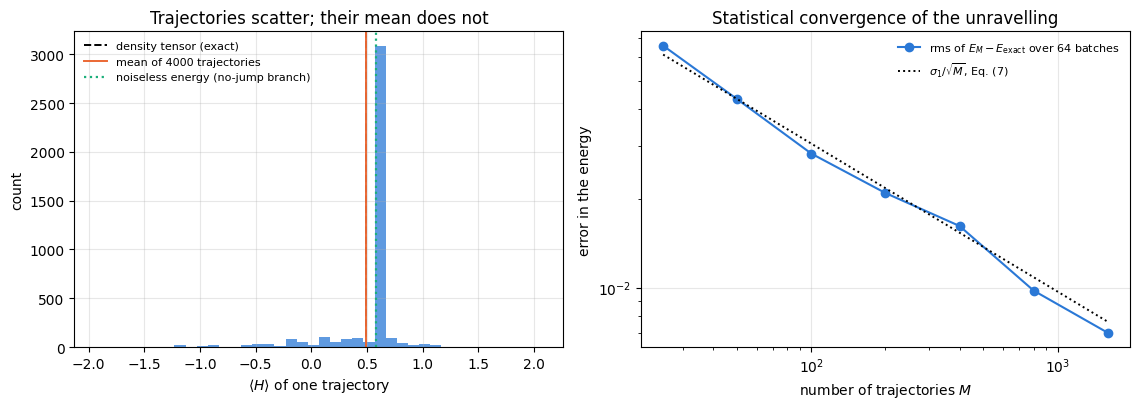

In [6]:
# ==============================================================================
# CHECKPOINT 1: at p = 0 the noisy simulators must reproduce the noiseless circuit exactly
# ==============================================================================
theta_test = jax.random.uniform(jax.random.PRNGKey(0), (hea_num_params(N_Q, 3),), minval=-jnp.pi, maxval=jnp.pi)
psi_pure = hardware_efficient_ansatz(theta_test, N_Q, 3)
err_dm = max_abs(noisy_hea_dm(theta_test, N_Q, 3, 0.0, 0.0) - to_dm(psi_pure))
psi_traj0 = noisy_hea_mcwf(jax.random.PRNGKey(1), theta_test, N_Q, 3, 0.0, 0.0)
err_mc = max_abs(psi_traj0 - psi_pure)
print("p = 0 against the engine's `hardware_efficient_ansatz`:")
print(f"  density tensor     max |rho - |psi><psi||  = {err_dm:.2e}")
print(f"  single trajectory  max |psi_traj - psi|    = {err_mc:.2e}")
assert err_dm < TOL and err_mc < TOL

# ==============================================================================
# CHECKPOINT 2: with noise, the trajectory average must reproduce the density tensor
# ==============================================================================
M_CHK = 4000
th_chk = theta_test[:hea_num_params(N_Q, L_DEF)]
E_ref = float(jax.jit(lambda t: energy_dm(TERMS, noisy_hea_dm(t, N_Q, L_DEF, P1_RATIO * P2_DEF, P2_DEF)))(th_chk))
E_ideal_chk = float(energy(TERMS, hardware_efficient_ansatz(th_chk, N_Q, L_DEF)))
traj_energy = jax.jit(jax.vmap(lambda k: energy(TERMS, noisy_hea_mcwf(k, th_chk, N_Q, L_DEF,
                                                                     P1_RATIO * P2_DEF, P2_DEF))))
samples = np.asarray(jax.block_until_ready(traj_energy(jax.random.split(jax.random.PRNGKey(7), M_CHK))))
E_mc, se_mc = mean_and_se(samples)
print(f"\nenergy of the noisy state at a random theta (p2 = {P2_DEF}):")
print(f"  density tensor (exact)      E = {E_ref:.6f}")
print(f"  {M_CHK} trajectories          E = {E_mc:.6f} +- {se_mc:.6f}")
print(f"  deviation = {abs(E_mc - E_ref) / se_mc:.2f} standard errors")
assert abs(E_mc - E_ref) < 5 * se_mc

# WRONG CONTROLS: the same test must REJECT models that differ from the simulated one
E_bug = float(energy_dm(TERMS, noisy_hea_dm(th_chk, N_Q, L_DEF, P1_RATIO * P2_DEF, P2_DEF, cz_both=False)))
for lab, E_wrong in (("noiseless circuit", E_ideal_chk), ("channel on one qubit of each CZ only", E_bug)):
    z = abs(E_mc - E_wrong) / se_mc
    print(f"  control, {lab:38s} E = {E_wrong:.6f}   deviation = {z:5.1f} standard errors")
    assert z > 5

# anatomy of the histogram: the no-jump branch reproduces the NOISELESS state
n_loc1 = N_Q * (L_DEF + 1)                     # channels of strength p1
n_loc2 = 2 * (N_Q - 1) * L_DEF                 # channels of strength p2
P_nojump = (1 - P1_RATIO * P2_DEF) ** n_loc1 * (1 - P2_DEF) ** n_loc2
print(f"\n  noiseless energy at these angles {E_ideal_chk:.6f};  fraction of trajectories exactly there "
      f"{np.mean(np.abs(samples - E_ideal_chk) < 1e-9):.4f}")
print(f"  probability of no jump at any of the {n_loc1 + n_loc2} noise locations = {P_nojump:.4f};  "
      f"spread of the samples {np.std(samples, ddof=1):.3f};  {np.mean(samples < -1):.4f} of them below -1")

# convergence of the trajectory estimate with M: rms error over 64 INDEPENDENT batches at each M
N_BATCH, Ms = 64, np.array([25, 50, 100, 200, 400, 800, 1600])
big = np.asarray(jax.block_until_ready(
    traj_energy(jax.random.split(jax.random.PRNGKey(8), N_BATCH * int(Ms[-1])))))
sigma1 = float(np.std(big, ddof=1))            # spread of ONE trajectory
rms = np.array([np.sqrt(np.mean((big[:N_BATCH * m].reshape(N_BATCH, m).mean(axis=1) - E_ref) ** 2)) for m in Ms])
print(f"\n  rms error over {N_BATCH} independent batches divided by sigma/sqrt(M):")
print("   " + "  ".join(f"M={m}: {r / (sigma1 / np.sqrt(m)):.2f}" for m, r in zip(Ms, rms)))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].hist(samples, bins=40, color=PALETTE[0], alpha=0.75)
axes[0].axvline(E_ref, color="k", ls="--", lw=1.4, label="density tensor (exact)")
axes[0].axvline(E_mc, color=PALETTE[1], ls="-", lw=1.4, label=f"mean of {M_CHK} trajectories")
axes[0].axvline(E_ideal_chk, color=PALETTE[2], ls=":", lw=1.6, label="noiseless energy (no-jump branch)")
axes[0].set_xlabel(r"$\langle H\rangle$ of one trajectory"); axes[0].set_ylabel("count")
axes[0].set_title("Trajectories scatter; their mean does not"); axes[0].legend(fontsize=8)
axes[1].loglog(Ms, rms, MARKERS[0] + "-", ms=6, color=PALETTE[0],
               label=f"rms of $E_M - E_{{\\mathrm{{exact}}}}$ over {N_BATCH} batches")
axes[1].loglog(Ms, sigma1 / np.sqrt(Ms), "k:", lw=1.4, label=r"$\sigma_1/\sqrt{M}$, Eq. (7)")
axes[1].set_xlabel("number of trajectories $M$"); axes[1].set_ylabel("error in the energy")
axes[1].set_title("Statistical convergence of the unravelling"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Two simulators built from completely different primitives — one sums over Kraus indices inside an einsum on a
rank-$2N$ tensor, the other samples a single Kraus operator per noise location on a rank-$N$ tensor — agree on the
energy of the same noisy state, within $0.32$ standard errors. Agreement alone would also be produced by a test too
weak to detect anything, which is what the two wrong controls exclude: the same $4000$ trajectories reject the
noiseless energy at $18$ standard errors and a plausible bug (the channel applied to only one qubit of each $CZ$) at
$7$ standard errors.

The left panel shows *why* the agreement has to be stated with an error bar. A single trajectory is a pure state with
its own energy. With probability $(1-p_1)^{12}(1-p_2)^{12}=0.766$ no jump happens anywhere, every Kraus operator
drawn is the identity, and the trajectory is the noiseless state: the tall bar is exactly at the noiseless energy
$0.576$, held by $76\%$ of the samples. The remaining quarter spreads over the whole spectrum, down to below $-1$, and
pulls the mean to $0.488$; the spread of single trajectories is $0.30$. No single trajectory "is" the noisy state,
and the most frequent one is not even close to its mean. The right panel draws $64$ independent batches at every
$M$ and shows that the rms error of the batch mean equals $\sigma_1/\sqrt M$ of Eq. (7), $\sigma_1$ being the
spread of one trajectory, to within the $\approx10\%$ scatter expected from $64$ batches.

> **Numerical practice.** Quoting a trajectory result without its standard error is not a measurement. In the
> comparisons below, every trajectory number is reported as mean $\pm$ standard error, and "agreement" always means
> "within a few standard errors", never "the digits look similar".

## 5. What noise does to the cost landscape

### 5.1 A Pauli operator under a depolarising channel

The cost is a sum of Pauli expectation values, so it is enough to know what the channel does to one Pauli string. Work
in the Heisenberg picture: $\mathrm{Tr}\bigl(P\,\mathcal D_p(\rho)\bigr)=\mathrm{Tr}\bigl(\mathcal D_p^\dagger(P)\,\rho\bigr)$,
where the adjoint channel is obtained by moving the Kraus operators to the other side of the trace. Since all Kraus
operators here are (multiples of) Hermitian Paulis, $\mathcal D_p^\dagger=\mathcal D_p$ as a map on operators. Take
$P=Z$ on the qubit the channel acts on:

$$\mathcal D_p^\dagger(Z)=(1-p)Z+\frac p3\bigl(XZX+YZY+ZZZ\bigr)=(1-p)Z+\frac p3(-Z-Z+Z)
  =\Bigl(1-\frac{4p}{3}\Bigr)Z=\lambda Z,\tag{8}$$

using $XZX=-Z$, $YZY=-Z$, $ZZZ=Z$. The same algebra gives $\lambda X$ and $\lambda Y$ — every non-identity Pauli is an
eigenoperator of the depolarising channel with eigenvalue $\lambda=1-4p/3$ — while $\mathcal D_p^\dagger(\mathbb 1)=\mathbb 1$.

A Pauli **string** of weight $w$ (non-identity on $w$ qubits) therefore picks up one factor $\lambda$ per channel
acting on a qubit in its support. If every qubit passes through $c$ channels per layer and there are $D$ layers, and
**if the string is not changed by the intervening unitaries**, then

$$\langle P\rangle_{\rm noisy}=\lambda^{\,w\,c\,D}\,\langle P\rangle_{\rm ideal},\qquad \lambda=1-\frac{4p}{3}.\tag{9}$$

Equation (9) says that the whole landscape is squeezed towards zero, exponentially in the depth, and *faster for
observables of higher weight*. Since $\mathrm{Tr}(\hat H)=0$ for a Hamiltonian built from non-identity Pauli strings,
zero is also the value of the cost on the maximally mixed state. **The landscape flattens towards the maximally mixed
value.**

The bold assumption is the weak point. In a real circuit the unitaries between the noise layers rotate $P$ into a
*sum* of Pauli strings, and the weight can change in either direction: $CZ$ maps $X\otimes\mathbb 1$ to
$X\otimes Z$ (weight $1\to2$) and $X\otimes Z$ back to $X\otimes\mathbb 1$ (weight $2\to1$). Equation (9) with the
weight of a term of $\hat H$ is therefore neither an upper nor a lower bound on the contraction of that term in a real
circuit, only an estimate. Step 3 verifies Eq. (9) exactly in a setting where the assumption holds; Section 5.2 and
Section 8 measure how far a real circuit departs from it, in opposite directions.

In [7]:
# ==============================================================================
# STEP 3: the contraction law of Eq. (9), where its assumptions hold exactly
# ==============================================================================
# Setting: a fixed Haar-random state, then D rounds of depolarising noise on EVERY qubit and nothing else
# (c = 1 channel per qubit per round, no unitaries in between) -> Eq. (9) should be exact.
psi_rand = haar_state(jax.random.PRNGKey(3), N_Q)
rho_rand = to_dm(psi_rand)
P_TEST = (("ZIII", 1), ("XXII", 2), ("XYZI", 3), ("XYZX", 4))
p_c = 0.05
lam_c = 1 - 4 * p_c / 3
print(f"D rounds of depolarising noise (p = {p_c}, lambda = 1 - 4p/3 = {lam_c:.6f}) on all {N_Q} qubits")
print(f"{'string':>8s} {'w':>2s} {'D':>2s} {'<P> measured':>14s} {'lambda^(wD) <P>_0':>19s} {'error':>10s}")
for ops, w in P_TEST:
    ideal = float(expect_pauli_string(psi_rand, ops))
    for D in (1, 3, 6):
        rho_d = rho_rand
        for _ in range(D):
            for q in range(N_Q):
                rho_d = apply_kraus_dm(rho_d, kraus_depolarizing(p_c), [q])
        got = float(expect_pauli_string_dm(rho_d, ops))
        pred = lam_c ** (w * D) * ideal
        print(f"{ops:>8s} {w:2d} {D:2d} {got:14.8f} {pred:19.8f} {abs(got - pred):10.1e}")
        assert abs(got - pred) < 1e-9

D rounds of depolarising noise (p = 0.05, lambda = 1 - 4p/3 = 0.933333) on all 4 qubits
  string  w  D   <P> measured   lambda^(wD) <P>_0      error
    ZIII  1  1    -0.35982302         -0.35982302    2.8e-16
    ZIII  1  3    -0.31344583         -0.31344583    3.9e-16
    ZIII  1  6    -0.25484307         -0.25484307    7.2e-16
    XXII  2  1    -0.03737327         -0.03737327    2.8e-17
    XXII  2  3    -0.02836013         -0.02836013    7.3e-17
    XXII  2  6    -0.01874688         -0.01874688    8.0e-17
    XYZI  3  1    -0.03376335         -0.03376335    3.5e-17
    XYZI  3  3    -0.02231856         -0.02231856    3.5e-17
    XYZI  3  6    -0.01199492         -0.01199492    5.4e-17
    XYZX  4  1    -0.27215023         -0.27215023    2.8e-16
    XYZX  4  3    -0.15671224         -0.15671224    3.9e-16
    XYZX  4  6    -0.06847692         -0.06847692    3.3e-16


Equation (9) is exact to round-off in every case, and the pattern of the numbers is the physics: at $p=0.05$ one round
of noise multiplies a weight-1 observable by $0.933$ and a weight-4 observable by $0.933^4=0.759$; after six rounds
the weight-1 expectation value retains $66\%$ of its ideal size and the weight-4 one retains $19\%$. **Collective,
high-weight observables are destroyed first** — which is the same statement as the fragility of GHZ coherences under
local noise.

### 5.2 A slice through the noisy cost landscape

We now put a real circuit between the noise layers and look at the cost itself. Fix a random $\boldsymbol\theta$, vary
one angle across its full period, and plot $C(\boldsymbol\theta)$ for several noise strengths. The noise probability
is a *traced* argument of `noisy_hea_dm`, so one `vmap` over the noise axis and one over the angle axis compile into a
single program.

amplitude of the one-angle slice: p2=0 -> 0.6023;  p2=0.05 -> 0.4328;  p2=0.10 -> 0.3025;  p2=0.25 -> 0.0868
fit amplitude(p) / amplitude(0) = lambda^n_eff  ->  n_eff = 4.79
  counted exponent for a weight-1 Pauli term over L=2 layers: 3.30
  counted exponent for a weight-2 Pauli term over L=2 layers: 7.27


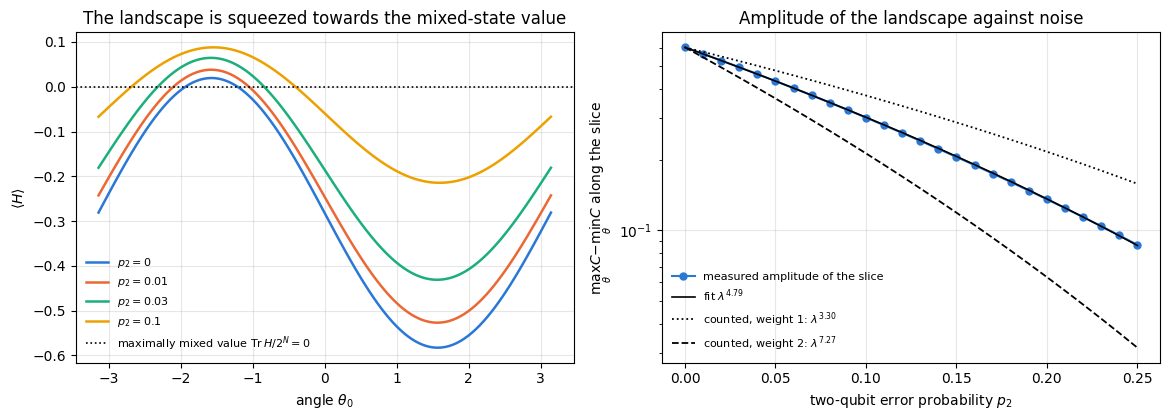

In [8]:
# ==============================================================================
# STEP 4: one-angle slices of the noisy cost, and the amplitude of the landscape vs p
# ==============================================================================
P_SLICE = jnp.asarray([0.0, 0.01, 0.03, 0.10])
n_par_def = hea_num_params(N_Q, L_DEF)
theta_slice = jax.random.uniform(jax.random.PRNGKey(12), (n_par_def,), minval=-jnp.pi, maxval=jnp.pi)
angles = jnp.linspace(-jnp.pi, jnp.pi, 121)


@jax.jit
def slice_cost(p, phi):
    """Cost as a function of angle 0 and of the two-qubit error probability -- both traced."""
    th = theta_slice.at[0].set(phi)
    return energy_dm(TERMS, noisy_hea_dm(th, N_Q, L_DEF, P1_RATIO * p, p))


curves = np.asarray(jax.vmap(lambda p: jax.vmap(lambda a: slice_cost(p, a))(angles))(P_SLICE))

P_AMP = jnp.asarray(np.linspace(0.0, 0.25, 26))
amp = np.asarray(jax.jit(jax.vmap(lambda p: jnp.max(jax.vmap(lambda a: slice_cost(p, a))(angles))
                                  - jnp.min(jax.vmap(lambda a: slice_cost(p, a))(angles))))(P_AMP))

# Effective exponent: fit  ln(amp/amp_0) = n_eff * ln(lambda)  with lambda = 1 - 4 p / 3.
lam_axis = 1 - 4 * np.asarray(P_AMP) / 3
n_eff = float(np.polyfit(np.log(lam_axis[1:]), np.log(amp[1:] / amp[0]), 1)[0])
# Counted exponents for a single Pauli string of weight w, L layers (Section 4.1):
#   CZ channels per layer: weight-1 term -> mean 1.5 per qubit; weight-2 term on a bond -> mean 10/3
#   rotation-block channels: w per layer+1, at strength p1 = P1_RATIO * p2
n_w1 = 1.5 * L_DEF + P1_RATIO * 1 * (L_DEF + 1)
n_w2 = (10 / 3) * L_DEF + P1_RATIO * 2 * (L_DEF + 1)
print(f"amplitude of the one-angle slice: p2=0 -> {amp[0]:.4f};  "
      f"p2=0.05 -> {amp[int(np.argmin(np.abs(np.asarray(P_AMP) - 0.05)))]:.4f};  "
      f"p2=0.10 -> {amp[int(np.argmin(np.abs(np.asarray(P_AMP) - 0.10)))]:.4f};  "
      f"p2=0.25 -> {amp[-1]:.4f}")
print(f"fit amplitude(p) / amplitude(0) = lambda^n_eff  ->  n_eff = {n_eff:.2f}")
print(f"  counted exponent for a weight-1 Pauli term over L={L_DEF} layers: {n_w1:.2f}")
print(f"  counted exponent for a weight-2 Pauli term over L={L_DEF} layers: {n_w2:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3))
for j, p in enumerate(np.asarray(P_SLICE)):
    axes[0].plot(np.asarray(angles), curves[j], "-", lw=1.8, color=PALETTE[j], label=f"$p_2={p:g}$")
axes[0].axhline(TRACE_H / 2 ** N_Q, color="k", ls=":", lw=1.2,
                label=r"maximally mixed value $\mathrm{Tr}\,H/2^N=0$")
axes[0].set_xlabel(r"angle $\theta_0$"); axes[0].set_ylabel(r"$\langle H\rangle$")
axes[0].set_title("The landscape is squeezed towards the mixed-state value"); axes[0].legend(fontsize=8)

axes[1].semilogy(np.asarray(P_AMP), amp, MARKERS[0] + "-", ms=5, color=PALETTE[0],
                 label="measured amplitude of the slice")
axes[1].semilogy(np.asarray(P_AMP), amp[0] * lam_axis ** n_eff, "k-", lw=1.2,
                 label=rf"fit $\lambda^{{{n_eff:.2f}}}$")
axes[1].semilogy(np.asarray(P_AMP), amp[0] * lam_axis ** n_w1, "k:", lw=1.3,
                 label=rf"counted, weight 1: $\lambda^{{{n_w1:.2f}}}$")
axes[1].semilogy(np.asarray(P_AMP), amp[0] * lam_axis ** n_w2, "k--", lw=1.3,
                 label=rf"counted, weight 2: $\lambda^{{{n_w2:.2f}}}$")
axes[1].set_xlabel(r"two-qubit error probability $p_2$")
axes[1].set_ylabel(r"$\max_\theta C-\min_\theta C$ along the slice")
axes[1].set_title("Amplitude of the landscape against noise"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The left panel shows the shape of the slice surviving while its amplitude shrinks: the maxima and minima stay at
almost the same angles, and the mean of the curve moves towards $\mathrm{Tr}\,\hat H/2^N=0$, the value the cost takes
on the maximally mixed state (the maximum, which lies slightly above zero, rises with $p_2$ because the whole curve
is drawn towards zero from below). That is the behaviour Eq. (9) predicts. Whether the minimum stays *exactly* in place
is decided in Sections 6 and 7.

Each slice is a pure sinusoid in $\theta_0$, with or without noise: a channel is linear in $\rho$, and $\rho$ depends on
one rotation angle only through $\cos\theta_0$ and $\sin\theta_0$, so the amplitude of a slice is a single number.

The right panel turns the observation into a number. The measured amplitude follows a clean power law in $\lambda$
over the whole range, $\mathrm{amplitude}\propto\lambda^{4.79}$ — the fitted line and the data are
indistinguishable from $p_2=0$ to $p_2=0.25$, so Eq. (9) has the right *functional form* even for a full circuit.
The exponent, however, is not the one a single Pauli weight predicts. Counting noise locations for $L=2$ layers as in
Section 4.1 gives $3.30$ for a weight-1 term ($X_q$ in the field part of $\hat H$) and $7.27$ for a weight-2 term
($X_iX_{i+1}$ and its partners), and the measured $4.79$ sits between them, *below* the count for the two-body terms
that dominate $\hat H$.

The amplitude of a *one-angle* slice is not the size of
one Pauli expectation value: it is the size of the part of $C$ that depends on $\theta_0$, and that part is a mixture
of contributions of different weights sitting at different distances from the qubit whose angle is being scanned.
Equation (9) therefore predicts the family of curves; which member of the family applies has to be measured.

> **Common pitfall.** "The landscape flattens" and "the minimum moves" are separate statements. A flattening alone
> leaves the minimum in place; a flattening that treats different Pauli strings differently, as local noise does,
> moves it. Sections 6 and 7 separate the two cases.

## 6. Global depolarising noise leaves the minimum exactly where it was

### 6.1 The channel and its two properties

The **global** depolarising channel on $N$ qubits replaces the state by the maximally mixed one with probability $q$:

$$\mathcal G_q(\rho)=(1-q)\,\rho+q\,\frac{\mathbb 1}{2^N}.\tag{10}$$

**Property 1 — it commutes with every unitary.** For any unitary $V$,

$$V\,\mathcal G_q(\rho)\,V^\dagger=(1-q)V\rho V^\dagger+q\,\frac{V\mathbb 1V^\dagger}{2^N}
  =(1-q)V\rho V^\dagger+q\,\frac{\mathbb 1}{2^N}=\mathcal G_q\bigl(V\rho V^\dagger\bigr),\tag{11}$$

because $V\mathbb 1V^\dagger=\mathbb 1$. **Property 2 — global depolarising channels compose into one.** Applying
$\mathcal G_{q_1}$ then $\mathcal G_{q_2}$ gives $\mathcal G_q$ with $1-q=(1-q_1)(1-q_2)$, since the identity is a
fixed point of every such channel.

Together these have a strong consequence. A circuit in which a global depolarising channel of strength $q_l$ follows
layer $l$ is **identical** to the noiseless circuit followed by one global depolarising channel of total strength
$1-q=\prod_l(1-q_l)$: commute every channel through all the later unitaries with Eq. (11), then merge them with
Property 2.

### 6.2 The cost, and why its minimiser does not move

The cost of the noisy state is therefore

$$C_{\rm noisy}(\boldsymbol\theta)=\mathrm{Tr}\bigl(\hat H\,\mathcal G_q(\vert\psi(\boldsymbol\theta)\rangle\langle\psi(\boldsymbol\theta)\vert)\bigr)
  =(1-q)\,C(\boldsymbol\theta)+q\,\frac{\mathrm{Tr}\,\hat H}{2^N}.\tag{12}$$

Both $q$ and $\mathrm{Tr}\hat H/2^N$ are independent of $\boldsymbol\theta$, and $1-q>0$ for $q<1$. An affine function
of $C$ with a positive slope is minimised exactly where $C$ is:

$$\arg\min_{\boldsymbol\theta}C_{\rm noisy}=\arg\min_{\boldsymbol\theta}C,\qquad
  \nabla C_{\rm noisy}=(1-q)\,\nabla C.\tag{13}$$

The *location* of every stationary point, the ordering of every pair of parameter values, and the direction of every
gradient are untouched. What this noise destroys is the *scale*: the gradient shrinks by $1-q=\prod_l(1-q_l)$, which
is exponentially small in the depth. The same shrinking, produced by local noise, is measured in Section 8 as a
noise-induced barren plateau. For our Hamiltonian $\mathrm{Tr}\hat H=0$, so Eq. (12) is a pure rescaling.

In [9]:
# ==============================================================================
# STEP 5: the global depolarising channel -- commutation, composition, and Eqs. (12)-(13)
# ==============================================================================
def apply_global_depolarizing(rho, q):
    """Global depolarising channel, Eq. (10):  rho -> (1-q) rho + q * 1/2^N.

    IMPLEMENTATION  the maximally mixed state is the identity matrix reshaped to a rank-2N tensor, divided by 2^N.
    """
    N = rho.ndim // 2
    eye = jnp.eye(2 ** N, dtype=rho.dtype).reshape((2,) * (2 * N))
    return (1 - q) * rho + q * eye / 2 ** N


q_g = 0.3
rho_g = to_dm(hardware_efficient_ansatz(theta_slice, N_Q, L_DEF))
V4 = haar_unitary(jax.random.PRNGKey(5), 4)                                  # an arbitrary 2-qubit unitary
lhs = apply_gate_dm(apply_global_depolarizing(rho_g, q_g), V4, [1, 2])
rhs = apply_global_depolarizing(apply_gate_dm(rho_g, V4, [1, 2]), q_g)
print(f"Property 1 (Eq. 11): max |V G_q(rho) V^dag - G_q(V rho V^dag)| = {max_abs(lhs - rhs):.2e}")
assert max_abs(lhs - rhs) < TOL

q1, q2 = 0.2, 0.35
comp = apply_global_depolarizing(apply_global_depolarizing(rho_g, q1), q2)
merged = apply_global_depolarizing(rho_g, 1 - (1 - q1) * (1 - q2))
print(f"Property 2 (composition): max |G_q2 o G_q1 - G_q| = {max_abs(comp - merged):.2e}")
assert max_abs(comp - merged) < TOL

C_ideal = float(energy(TERMS, hardware_efficient_ansatz(theta_slice, N_Q, L_DEF)))
C_noisy = float(energy_dm(TERMS, apply_global_depolarizing(rho_g, q_g)))
print(f"\nEq. (12) at a random theta, q = {q_g}:")
print(f"  C_ideal                       = {C_ideal:+.12f}")
print(f"  C_noisy (measured)            = {C_noisy:+.12f}")
print(f"  (1-q) C_ideal + q Tr H / 2^N  = {(1 - q_g) * C_ideal + q_g * TRACE_H / 2 ** N_Q:+.12f}")
assert abs(C_noisy - ((1 - q_g) * C_ideal + q_g * TRACE_H / 2 ** N_Q)) < TOL

# the gradient is rescaled, not rotated (Eq. 13)
g_ideal = jax.grad(lambda t: energy(TERMS, hardware_efficient_ansatz(t, N_Q, L_DEF)))(theta_slice)
g_noisy = jax.grad(lambda t: energy_dm(TERMS, apply_global_depolarizing(
    to_dm(hardware_efficient_ansatz(t, N_Q, L_DEF)), q_g)))(theta_slice)
cos_angle = float(jnp.dot(g_ideal, g_noisy) / (jnp.linalg.norm(g_ideal) * jnp.linalg.norm(g_noisy)))
print(f"  |grad C_noisy| / |grad C_ideal| = {float(jnp.linalg.norm(g_noisy) / jnp.linalg.norm(g_ideal)):.12f}"
      f"   vs 1-q = {1 - q_g}")
print(f"  cosine of the angle between the two gradients = {cos_angle:.12f}")
assert abs(cos_angle - 1.0) < TOL

Property 1 (Eq. 11): max |V G_q(rho) V^dag - G_q(V rho V^dag)| = 4.39e-17
Property 2 (composition): max |G_q2 o G_q1 - G_q| = 2.78e-17

Eq. (12) at a random theta, q = 0.3:
  C_ideal                       = +0.002285966153
  C_noisy (measured)            = +0.001600176307
  (1-q) C_ideal + q Tr H / 2^N  = +0.001600176307


  |grad C_noisy| / |grad C_ideal| = 0.700000000000   vs 1-q = 0.7
  cosine of the angle between the two gradients = 1.000000000000


max |C_noisy(theta) - [(1-q) C_ideal(theta) + q Tr H / 2^N]| over the 81x81 grid: 1.67e-16
grid points within 1e-09 of the minimum:
  q = 0.0 : 2 point(s) at (-1.5708, -2.9845), (+1.5708, +0.1571)   C = -0.684761
  q = 0.8 : 2 point(s) at (-1.5708, -2.9845), (+1.5708, +0.1571)   C = -0.136952
  the two minimising sets are identical: True
  ratio of the two minima 0.200000000000  vs 1-q = 0.19999999999999996


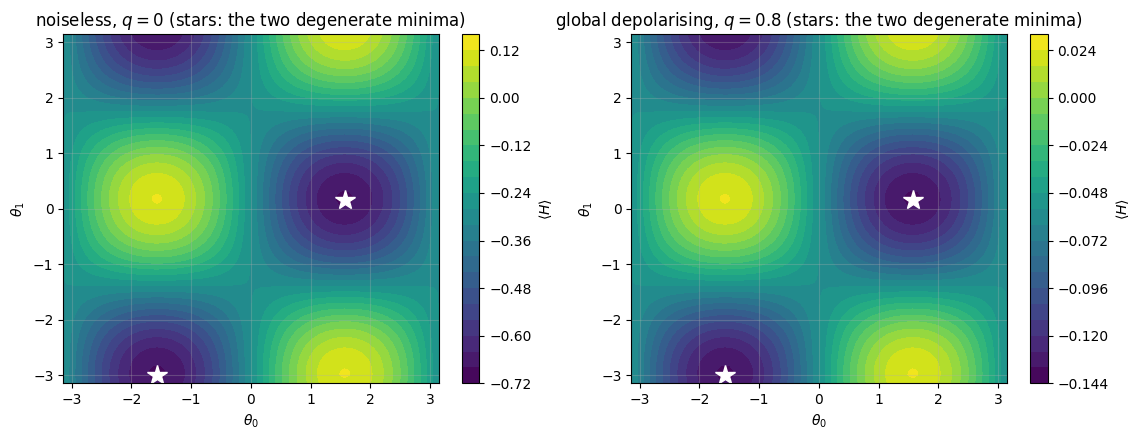

In [10]:
# ==============================================================================
# STEP 6: the minimum of a two-angle slice, with and without global depolarising noise
# ==============================================================================
grid2 = jnp.linspace(-jnp.pi, jnp.pi, 81)


@jax.jit
def surface(q):
    def one(a, b):
        th = theta_slice.at[0].set(a).at[1].set(b)
        return energy_dm(TERMS, apply_global_depolarizing(to_dm(hardware_efficient_ansatz(th, N_Q, L_DEF)), q))
    return jax.vmap(lambda a: jax.vmap(lambda b: one(a, b))(grid2))(grid2)


Q_SURF = 0.8
S0, Sq = np.asarray(surface(0.0)), np.asarray(surface(Q_SURF))

# The strong statement: the two surfaces are the SAME function, up to the affine map of Eq. (12).
affine_err = float(np.max(np.abs(Sq - ((1 - Q_SURF) * S0 + Q_SURF * TRACE_H / 2 ** N_Q))))
print(f"max |C_noisy(theta) - [(1-q) C_ideal(theta) + q Tr H / 2^N]| over the {grid2.size}x{grid2.size} grid: "
      f"{affine_err:.2e}")
assert affine_err < TOL

# Consequence: the sets of grid minima coincide.  (This landscape has TWO exactly degenerate global minima,
# so `argmin`, which breaks ties arbitrarily, is not the right thing to compare -- the minimising SET is.)
tol_min = 1e-9
set0 = set(map(tuple, np.argwhere(S0 <= S0.min() + tol_min)))
setq = set(map(tuple, np.argwhere(Sq <= Sq.min() + tol_min * (1 - Q_SURF))))
print(f"grid points within {tol_min:g} of the minimum:")
print(f"  q = 0.0 : {len(set0)} point(s) at " + ", ".join(
    f"({float(grid2[i]):+.4f}, {float(grid2[j]):+.4f})" for i, j in sorted(set0)) + f"   C = {S0.min():+.6f}")
print(f"  q = {Q_SURF} : {len(setq)} point(s) at " + ", ".join(
    f"({float(grid2[i]):+.4f}, {float(grid2[j]):+.4f})" for i, j in sorted(setq)) + f"   C = {Sq.min():+.6f}")
print(f"  the two minimising sets are identical: {set0 == setq}")
print(f"  ratio of the two minima {Sq.min() / S0.min():.12f}  vs 1-q = {1 - Q_SURF}")
assert set0 == setq

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.5))
for ax, S, ttl in zip(axes, (S0, Sq), ("noiseless, $q=0$", f"global depolarising, $q={Q_SURF}$")):
    im = ax.contourf(np.asarray(grid2), np.asarray(grid2), S.T, levels=24, cmap="viridis")
    for i, j in sorted(set0):
        ax.plot([float(grid2[i])], [float(grid2[j])], "w*", ms=15)
    ax.set_xlabel(r"$\theta_0$"); ax.set_ylabel(r"$\theta_1$")
    ax.set_title(ttl + " (stars: the two degenerate minima)")
    fig.colorbar(im, ax=ax, label=r"$\langle H\rangle$")
fig.tight_layout(); plt.show()

Both properties hold to machine precision, Eq. (12) reproduces the noisy cost to twelve digits, and the gradient is
rescaled by exactly $1-q$ with the cosine of the angle between the two gradients equal to $1$ — the noisy gradient
points in the same direction as the noiseless one.

The contour plots make the consequence visible. At $q=0.8$ only a fifth of the original contrast survives, so the
colour scale spans a fifth of the range; the *pattern* of the level sets is identical, and the two surfaces are
verified to be the same function up to the affine map of Eq. (12), grid point by grid point, to $10^{-16}$.

This landscape happens to have **two exactly degenerate global minima** — visible as the two dark spots, related by
$(\theta_0,\theta_1)\to(\theta_0+\pi,\theta_1+\pi)$ — which is why the comparison is made between the minimising
*sets* rather than between two calls to `argmin`: a tie is broken by round-off, and at $q=0.8$ the round-off falls
differently. The sets coincide, and the two minimum values are in the exact ratio $1-q$.

A variational algorithm running on a device whose only error is global depolarising noise converges to the same angles
as on a perfect device. It has to see through a landscape whose features are $(1-q)$ times as large, which requires
of order $(1-q)^{-2}$ times as many measurement shots for the same resolution (the single-shot variance of the
estimator changes as well, so the factor is not exact).

> **Physics insight.** This is the simplest instance of *optimal-parameter resilience* (Sharma, Khatri, Cerezo and
> Coles, 2020), who proved for variational *compiling* that the optimal parameters are unaffected by a broad class of
> noise models (measurement noise, gate noise, Pauli channel noise), showed it in a warm-up eigensolver for
> non-interacting spins with measurement noise, and speculated that the resilience extends to the variational
> eigensolver in general. Section 7 shows that for the eigensolver with local noise the minimum does move, and
> Section 10 measures by how much.

## 7. Local noise moves the minimum

Equation (11) used one specific property of the global channel: it maps $\rho$ to a combination of $\rho$ itself and
$\mathbb 1$, so it shrinks **every** traceless operator by the **same** factor $1-q$. Two weaker properties are not
enough.

* **Unitality**, $\mathcal E(\mathbb 1)=\mathbb 1$, is not enough. A local dephasing channel is unital, but it
  multiplies $X$ and $Y$ by $1-2p$ and leaves $Z$ alone, so it changes the relative weight of the terms of the cost.
* **Equal contraction of all Pauli operators on one qubit**, the property of the single-qubit depolarising channel
  (Eq. 8), is not enough on $N\geq2$ qubits. A string of weight $w$ is multiplied by $\lambda^w$ (Eq. 9), so one-body
  and two-body terms of $\hat H$ are contracted by different factors.

Amplitude damping fails on both counts and in addition is **not unital** — it drives every state towards
$\vert0\rangle$, so $\mathcal A_\gamma(\mathbb 1/2)=\tfrac12\mathrm{diag}(1+\gamma,1-\gamma)\neq\mathbb 1/2$.
Section 7.1 computes the consequence in closed form for one qubit; Section 7.2 treats the four-qubit circuit.

### 7.1 The exactly solvable one-qubit case

Take one qubit, the cost $C(\theta)=-\langle X\rangle-h\langle Z\rangle$ with a fixed $h>0$, and the one-parameter
ansatz $\vert\psi(\theta)\rangle=R_y(\theta)\vert0\rangle$, whose Bloch vector is
$\mathbf r=(\sin\theta,\,0,\,\cos\theta)$. Apply a channel after the gate and read off the Bloch map.

* **Noiseless:** $C(\theta)=-\sin\theta-h\cos\theta$. Setting $C'(\theta)=-\cos\theta+h\sin\theta=0$ gives

  $$\tan\theta_\star=\frac1h.\tag{14}$$

* **Depolarising**, which multiplies every Bloch component by $\lambda=1-4p/3$:
  $C_\lambda(\theta)=-\lambda(\sin\theta+h\cos\theta)=\lambda\,C(\theta)$. The minimiser is unchanged — this is
  Eq. (13) again, since a single-qubit depolarising channel *is* the global one for $N=1$.

* **Dephasing**, unital, whose Bloch map is $x\to(1-2p)x$, $y\to(1-2p)y$, $z\to z$:
  $C_p(\theta)=-(1-2p)\sin\theta-h\cos\theta$, and $C_p'(\theta)=0$ gives

  $$\tan\theta_\star(p)=\frac{1-2p}{h}.\tag{14a}$$

  The optimum rotates towards the pole, although the channel preserves $\mathbb 1$.

* **Amplitude damping**, whose Bloch map is $x\to\sqrt{1-\gamma}\,x$, $y\to\sqrt{1-\gamma}\,y$,
  $z\to(1-\gamma)z+\gamma$ (the last term is the non-unital piece):

  $$C_\gamma(\theta)=-\sqrt{1-\gamma}\,\sin\theta-h\bigl[(1-\gamma)\cos\theta+\gamma\bigr].$$

  Differentiating, $-\sqrt{1-\gamma}\cos\theta+h(1-\gamma)\sin\theta=0$, so

  $$\tan\theta_\star(\gamma)=\frac{\sqrt{1-\gamma}}{h(1-\gamma)}=\frac{1}{h\sqrt{1-\gamma}}.\tag{15}$$

The constant $-h\gamma$ is an offset and drops out of the derivative; what survives is that the transverse components
are damped by $\sqrt{1-\gamma}$ while the longitudinal one is damped by $1-\gamma$. **The two damping factors are
different, so their ratio changes with $\gamma$, and the optimal angle rotates towards the equator.** Dephasing moves
the optimum by the same mechanism in the opposite direction; only the depolarising channel, which damps all three
components equally, leaves it in place. Equation (15)
reduces to Eq. (14) at $\gamma=0$ and diverges as $\gamma\to1$: with complete damping the state is $\vert0\rangle$
whatever $\theta$ is, and the optimum becomes degenerate.

one qubit, C(theta) = -<X> - 0.5<Z>;  grid spacing 1.57e-04
                            case  theta* measured  theta* predicted   difference   C(theta*)
                       noiseless         1.107097          1.107149    -5.15e-05   -1.118034


              depolarising p=0.2         1.107097          1.107149    -5.15e-05   -0.819892
                 dephasing p=0.2         0.876033          0.876058    -2.49e-05   -0.781025


     amplitude damping gamma=0.3         1.174641          1.174589    +5.27e-05   -1.056918
     amplitude damping gamma=0.6         1.264491          1.264519    -2.79e-05   -0.963325


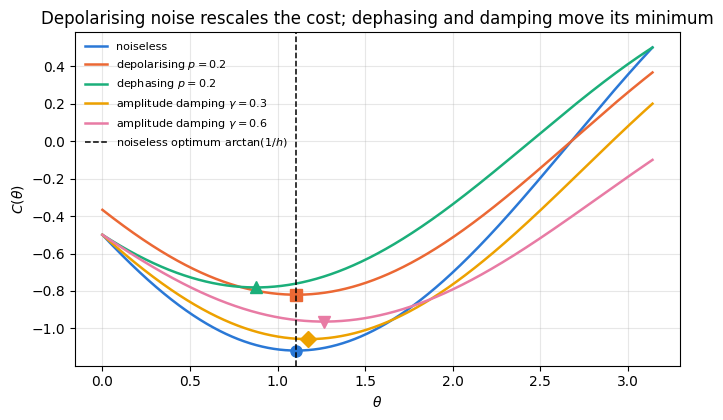

In [11]:
# ==============================================================================
# STEP 7: the one-qubit example, minimised on a fine grid and compared with Eqs. (14), (14a) and (15)
# ==============================================================================
H_FIELD = 0.5


def cost_1q(theta, chan, par):
    """C(theta) = -<X> - h<Z> for Ry(theta)|0> followed by the channel `chan(par)` -- density tensor, one qubit."""
    rho = apply_gate_dm(to_dm(zero_state(1)), ry(theta), [0])
    rho = apply_kraus_dm(rho, chan(par), [0])
    return -(expect_local_dm(rho, X, [0]) + H_FIELD * expect_local_dm(rho, Z, [0]))


fine = jnp.linspace(0.0, jnp.pi, 20001)
cases = [("noiseless", kraus_depolarizing, 0.0, np.arctan(1 / H_FIELD)),
         ("depolarising $p=0.2$", kraus_depolarizing, 0.2, np.arctan(1 / H_FIELD)),
         ("dephasing $p=0.2$", kraus_dephasing, 0.2, np.arctan((1 - 2 * 0.2) / H_FIELD)),
         ("amplitude damping $\\gamma=0.3$", kraus_amplitude_damping, 0.3,
          np.arctan(1 / (H_FIELD * np.sqrt(1 - 0.3)))),
         ("amplitude damping $\\gamma=0.6$", kraus_amplitude_damping, 0.6,
          np.arctan(1 / (H_FIELD * np.sqrt(1 - 0.6))))]

print(f"one qubit, C(theta) = -<X> - {H_FIELD}<Z>;  grid spacing {float(fine[1] - fine[0]):.2e}")
print(f"{'case':>32s} {'theta* measured':>16s} {'theta* predicted':>17s} {'difference':>12s} {'C(theta*)':>11s}")
fig, ax = plt.subplots(figsize=(7.0, 4.3))
for j, (name, chan, par, pred) in enumerate(cases):
    vals = np.asarray(jax.jit(jax.vmap(lambda t: cost_1q(t, chan, par)))(fine))
    tmin = float(fine[int(np.argmin(vals))])
    print(f"{name.replace('$', '').replace(chr(92) + 'gamma', 'gamma'):>32s} {tmin:16.6f} {pred:17.6f} "
          f"{tmin - pred:+12.2e} {vals.min():11.6f}")
    assert abs(tmin - pred) < 2e-3
    ax.plot(np.asarray(fine), vals, "-", lw=1.8, color=PALETTE[j], label=name)
    ax.plot([tmin], [vals.min()], MARKERS[j], ms=8, color=PALETTE[j])
ax.axvline(np.arctan(1 / H_FIELD), color="k", ls="--", lw=1.1, label=r"noiseless optimum $\arctan(1/h)$")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel(r"$C(\theta)$")
ax.set_title("Depolarising noise rescales the cost; dephasing and damping move its minimum")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The measured minimisers reproduce Eqs. (14), (14a) and (15) to the resolution of the grid — the differences in the
table are at most $5\cdot10^{-5}$, a third of the grid spacing $1.57\cdot10^{-4}$. The depolarising curve is a scaled
copy of the noiseless one and its minimum sits at $1.107097$, on the dashed line at $\arctan(1/h)=1.107149$; the
dephasing curve has its minimum at $0.876$ against the predicted $\arctan(1.2)=0.876058$; the two amplitude-damping
curves have their minima at $1.174641$ and $1.264491$, against the predicted $1.174589$ and $1.264519$ of Eq. (15).

The shifts are not small: at $\gamma=0.6$ the optimal angle has moved by $0.157$ radians, about $9$ degrees, and
dephasing at $p=0.2$ moves it by $0.23$ radians in the other direction. An algorithm that trains under such noise and
then reports its angles as "the" answer reports a biased answer, and the bias grows with the noise.

### 7.2 Many qubits: local depolarising noise deforms the cost

On $N$ qubits the single-qubit depolarising channel is no longer global, and Eq. (9) shows what replaces Eq. (12).
Take the simplest placement: the noiseless circuit, followed by $\mathcal D_p$ on every qubit. By Eq. (8) a Pauli
string of weight $w$ is multiplied by $\lambda^w$, so for our Hamiltonian, whose bond terms have weight $2$ and whose
field terms have weight $1$,

$$C_{\rm noisy}(\boldsymbol\theta)=\lambda^2\sum_{i}\langle J_{xx}X_iX_{i+1}+J_{yy}Y_iY_{i+1}+J_{zz}Z_iZ_{i+1}\rangle
  +\lambda\,h_x\sum_i\langle X_i\rangle=\lambda^2\,\langle\hat H'\rangle_{\boldsymbol\theta},
  \qquad \hat H'=\hat H\big\vert_{h_x\to h_x/\lambda}.\tag{15a}$$

The noisy cost is the noiseless cost of a **different Hamiltonian**, one with a stronger field, and its minimiser is
the best approximation to a different ground state. Only if every term of $\hat H$ had the same weight would the
minimiser stay put. With the channels interleaved with the gates, as in our circuit, there is no closed form, but the
test is simple. At the noiseless minimiser $\boldsymbol\theta^\star$ we have $\nabla C(\boldsymbol\theta^\star)=0$; if
the noisy minimiser is the same point, $\nabla C_{\rm noisy}(\boldsymbol\theta^\star)$ must vanish too. Expanding the
noisy cost to first order in the noise strength, $C_{\rm noisy}=C+p\,C_1+O(p^2)$, the gradient at
$\boldsymbol\theta^\star$ is $p\,\nabla C_1(\boldsymbol\theta^\star)+O(p^2)$: it grows linearly in $p$ unless
$\nabla C_1(\boldsymbol\theta^\star)=0$ by a symmetry, and the minimiser moves by an amount of order
$p\,\lVert\mathcal H^{-1}\nabla C_1\rVert$, with $\mathcal H$ the Hessian of $C$ at the minimum.

The code finds $\boldsymbol\theta^\star$ for $L=2$ with the quasi-Newton method BFGS (Numerical Recipes, §10.9;
`jax.scipy.optimize.minimize`, eight random starts in one `vmap`), checks Eq. (15a), and evaluates the gradient of the noisy cost at
$\boldsymbol\theta^\star$ for four noise models placed in the circuit as in Section 4.1. The global depolarising
channel after every layer is the control: by Eq. (13) its gradient is $(1-q)^{L+1}$ times the noiseless one, which is
zero up to the convergence of BFGS.

In [12]:
# ==============================================================================
# STEP 7b: does the minimiser of the four-qubit circuit move?  Gradient of the noisy cost at the noiseless optimum
# ==============================================================================
from jax.scipy.optimize import minimize


def global_noise_hea_dm(theta, N, layers, q):
    """The noiseless ansatz with a GLOBAL depolarising channel of strength q after every layer and at the end."""
    noiseless = kraus_depolarizing(0.0)
    th = theta.reshape(layers + 1, N, 2)
    rho = to_dm(zero_state(N))
    for l in range(layers):
        rho = apply_global_depolarizing(ent_block_dm(rot_block_dm(rho, th[l], noiseless, N), noiseless, N), q)
    return apply_global_depolarizing(rot_block_dm(rho, th[layers], noiseless, N), q)


cost_ideal_def = lambda t: energy(TERMS, hardware_efficient_ansatz(t, N_Q, L_DEF))
starts_bfgs, _ = random_starts(8, hea_num_params(N_Q, L_DEF), seed=2024)
sol, t_c, t_r = compile_then_run(
    jax.vmap(lambda s: minimize(cost_ideal_def, s, method="BFGS", tol=1e-12, options=dict(maxiter=2000))), starts_bfgs)
theta_opt = sol.x[int(jnp.argmin(sol.fun))]
E_opt = float(cost_ideal_def(theta_opt))
g_opt = max_abs(jax.grad(cost_ideal_def)(theta_opt))
hess_ev = np.linalg.eigvalsh(np.asarray(jax.hessian(cost_ideal_def)(theta_opt)))
print(f"BFGS from 8 starts (compile {t_c:.1f} s, run {t_r:.1f} s): best E = {E_opt:.8f}  (exact E0 = {E0_EXACT:.8f})")
print(f"  max |grad C(theta*)| = {g_opt:.1e};  Hessian eigenvalues from {hess_ev[0]:.1e} to {hess_ev[-1]:.2f}, "
      f"{int(np.sum(hess_ev < 1e-2))} of them below 1e-2")

# Eq. (15a): local depolarising AFTER the noiseless circuit = noiseless cost of H' with h_x -> h_x / lambda
p_end = 0.05
lam_end = 1 - 4 * p_end / 3
rho_end = to_dm(hardware_efficient_ansatz(theta_opt, N_Q, L_DEF))
for q in range(N_Q):
    rho_end = apply_kraus_dm(rho_end, kraus_depolarizing(p_end), [q])
TERMS_PRIME = heisenberg_terms(N_Q, Jxx=JXX, Jyy=JYY, Jzz=JZZ, hx=HX / lam_end)
lhs_end = float(energy_dm(TERMS, rho_end))
rhs_end = lam_end ** 2 * float(energy(TERMS_PRIME, hardware_efficient_ansatz(theta_opt, N_Q, L_DEF)))
print(f"\nEq. (15a) at p = {p_end}:  C_noisy = {lhs_end:.12f},  lambda^2 <H'> = {rhs_end:.12f}")
assert abs(lhs_end - rhs_end) < TOL

P_SHIFT = jnp.asarray([0.0025, 0.005, 0.01, 0.02])
MODELS = (("global depolarising (control)", lambda t, p: energy_dm(TERMS, global_noise_hea_dm(t, N_Q, L_DEF, p))),
          ("local depolarising", lambda t, p: energy_dm(TERMS, noisy_hea_dm(t, N_Q, L_DEF, P1_RATIO * p, p))),
          ("local dephasing", lambda t, p: energy_dm(TERMS, noisy_hea_dm(t, N_Q, L_DEF, P1_RATIO * p, p,
                                                                          kraus_dephasing, kraus_dephasing))),
          ("amplitude damping", lambda t, p: energy_dm(TERMS, noisy_hea_dm(t, N_Q, L_DEF, P1_RATIO * p, p,
                                                                            kraus_amplitude_damping,
                                                                            kraus_amplitude_damping))))
print(f"\nmax_k |dC_noisy/dtheta_k| at the noiseless optimum (noise strength p2 = p, p1 = {P1_RATIO} p)")
print(f"{'model':>30s} " + " ".join(f"{'p=' + format(float(p), 'g'):>10s}" for p in P_SHIFT) + f" {'(grad)/p':>10s}")
grad_at_opt = {}
for name, f in MODELS:
    g = np.asarray(jax.jit(jax.vmap(lambda p: jnp.max(jnp.abs(jax.grad(f)(theta_opt, p)))))(P_SHIFT))
    grad_at_opt[name] = g
    print(f"{name:>30s} " + " ".join(f"{v:10.2e}" for v in g) + f" {g[0] / float(P_SHIFT[0]):10.2f}")
assert grad_at_opt["global depolarising (control)"].max() <= g_opt * (1 + 1e-9)
for name, _ in MODELS[1:]:
    assert grad_at_opt[name].min() > 1e3 * g_opt

BFGS from 8 starts (compile 5.1 s, run 0.0 s): best E = -4.44771985  (exact E0 = -4.45484883)
  max |grad C(theta*)| = 4.4e-06;  Hessian eigenvalues from -4.3e-08 to 8.14, 4 of them below 1e-2

Eq. (15a) at p = 0.05:  C_noisy = -3.942284428256,  lambda^2 <H'> = -3.942284428256

max_k |dC_noisy/dtheta_k| at the noiseless optimum (noise strength p2 = p, p1 = 0.1 p)
                         model   p=0.0025    p=0.005     p=0.01     p=0.02   (grad)/p


 global depolarising (control)   4.33e-06   4.30e-06   4.23e-06   4.11e-06       0.00


            local depolarising   1.30e-02   2.55e-02   4.91e-02   9.08e-02       5.21


               local dephasing   2.38e-02   4.64e-02   8.85e-02   1.61e-01       9.51


             amplitude damping   5.91e-03   1.17e-02   2.32e-02   4.50e-02       2.37


BFGS reaches the noiseless optimum of this ansatz, $-4.44772$, about $7\cdot10^{-3}$ above the exact ground energy,
with a residual gradient of $4\cdot10^{-6}$. Equation (15a) holds to round-off. The gradient table separates the
models cleanly. Under global depolarising noise the gradient at $\boldsymbol\theta^\star$ stays at the noiseless
residual, reduced by the factor $(1-q)^{L+1}$: the minimiser does not move. Under each of the three local channels
the gradient is three to four orders of magnitude larger and grows almost in proportion to $p$ (each doubling of $p$
multiplies it by $1.85$–$1.96$), as the first-order argument requires, so the minimiser moves by an amount of order
$p$. Dephasing, which is unital, pushes hardest; damping, which is not, pushes least.

The Hessian at $\boldsymbol\theta^\star$ has one eigenvalue that is zero to the precision of BFGS (a redundant
direction of the ansatz) and three more below $10^{-2}$, against a largest eigenvalue of $8.1$: there are very soft
directions. Along those, a small force produces a large displacement that costs little noiseless energy. That
combination, large displacement and small energy penalty, is what Section 10 measures.

> **Physics insight.** The property that keeps the minimum in place is that the noise contracts **every** Pauli
> string of the cost by the **same** factor, which holds for global depolarising noise and for a single qubit under
> depolarising noise. Unitality does not suffice: local dephasing preserves the identity and still moves the
> minimum. Non-unital channels such as amplitude damping add a further bias, a preferred state towards which every
> noisy output is pulled.

## 8. Noise-induced barren plateaus

Notebook 40 measured the barren plateau of a *noiseless* circuit: for a hardware-efficient ansatz the variance of a
gradient component falls exponentially with the number of **qubits**. Wang and co-workers (2021) identified a second,
conceptually different mechanism caused by noise. For local Pauli noise acting on every qubit before and after each
of $L$ layers, with $q$ the largest factor by which the noise multiplies $X$, $Y$ or $Z$ ($q=\lambda$ for
depolarising noise), they proved an upper bound on **every** partial derivative of the noisy cost, at **every** point
of the landscape, proportional to $n^{1/2}q^{cL+1}$ with $c=1/(2\ln2)$ and a prefactor fixed by the Pauli
decompositions of the cost and the generators; the cost itself concentrates on its maximally mixed value
$\mathrm{Tr}\,\hat O/2^n$ with the same factor. When $L$ grows at least linearly with $n$ the gradient vanishes
exponentially in $n$, for any $q<1$. At fixed $N$ their bound decays exponentially with the **depth**. It covers
unital Pauli noise; amplitude damping is outside it.

The bound does not predict the rate for a particular circuit. A heuristic estimate follows from Eq. (9). If each noisy
layer multiplied every relevant Pauli expectation value by $\lambda^{wc}$, then after $L$ layers the cost — and with
it every derivative — would be compressed by $\lambda^{wcL}$, and a variance, being quadratic, by $\lambda^{2wcL}$:

$$\mathrm{Var}\bigl[\partial_kC\bigr]_{\rm noisy}\ \approx\ \lambda^{2wcL}\;\mathrm{Var}\bigl[\partial_kC\bigr]_{\rm noiseless},
  \qquad \ln\frac{\mathrm{Var}_{\rm noisy}}{\mathrm{Var}_{\rm noiseless}}\approx 2\,w\,c\,L\,\ln\lambda.\tag{16}$$

The counting of $c$ for our circuit was done in Section 4.1. A two-body term $Z_iZ_{i+1}$ on bond $(i,i+1)$ sees, per
layer, the $CZ$ channels of both its qubits: $1+2=3$ for the end bonds and $2+2=4$ for the middle one, so $10/3$ on
average over the three bonds of an $N=4$ chain, plus $2\times0.1$ from the two rotation-block channels at
$p_1=0.1p_2$ (to first order in $p$, a channel of strength $0.1p_2$ contributes $0.1$ to the exponent of
$\lambda$). Hence $wc=10/3+0.2=3.53$ for the dominant terms of $\hat H$, and Eq. (16) predicts a slope
$2\times3.53\times\ln\lambda$ in a plot of $\ln(\mathrm{Var}_{\rm noisy}/\mathrm{Var}_{\rm noiseless})$ against $L$.
Section 5.1 showed why this is only an estimate: the gates change the weight of the strings in both directions.

The measurement takes $R=96$ uniformly random parameter vectors at each depth, differentiates the noisy cost with
respect to all parameters by reverse-mode automatic differentiation **through the Kraus einsums**, and records the
sample variance of the first component. The same parameter vectors are used at every noise strength, so the ratio
$\mathrm{Var}_{\rm noisy}/\mathrm{Var}_{\rm noiseless}$ is a paired quantity, and its uncertainty is estimated by
resampling the $R$ vectors with replacement (bootstrap) and refitting. Because $p$ is a traced argument, one `vmap`
over noise strengths and one over random draws compile into a single program per depth.

variance of dC/dtheta_0 over 96 uniformly random parameter vectors (compilation 9.6 s, run 1.3 s; relative standard error of one variance ~ sqrt(2/(R-1)) = 0.15)
  L     n         p2=0     p2=0.005      p2=0.02
  1    16   2.6568e-01   2.5311e-01   2.1857e-01
  2    24   3.0589e-01   2.8080e-01   2.1755e-01
  4    40   2.4070e-01   2.0117e-01   1.1915e-01
  6    56   2.1209e-01   1.5841e-01   6.8325e-02
  8    72   2.0950e-01   1.3956e-01   4.4406e-02
 12   104   1.9009e-01   9.4384e-02   1.3439e-02

fitted exponential decay of the RATIO Var(p)/Var(0) against depth  (predicted slope 2*3.53*ln(1-4p/3))


  p2 = 0.0050:  measured slope -0.0590  (95% bootstrap interval [-0.0621, -0.0561])   Eq. (16) -0.0473   ratio 1.25 [1.19, 1.31]   weight-1 count -0.0214


  p2 = 0.0200:  measured slope -0.2220  (95% bootstrap interval [-0.2358, -0.2095])   Eq. (16) -0.1910   ratio 1.16 [1.10, 1.23]   weight-1 count -0.0865


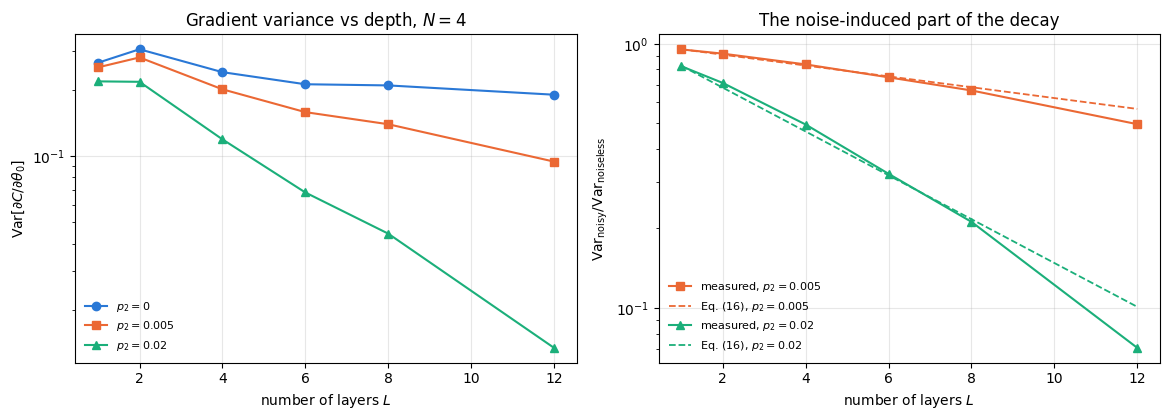

In [13]:
# ==============================================================================
# STEP 8: gradient variance against circuit depth, with and without noise
# ==============================================================================
# PARAMETERS
R_BP = 96                                   # random parameter vectors per depth
DEPTHS_BP = (1, 2, 4, 6, 8, 12)
P_BP = jnp.asarray([0.0, 0.005, 0.02])      # two-qubit error probabilities

var_bp, g0_bp = {}, {}
t_comp_bp = t_run_bp = 0.0
for L in DEPTHS_BP:
    n_par = hea_num_params(N_Q, L)
    th_bp = jax.random.uniform(jax.random.PRNGKey(10 + L), (R_BP, n_par), minval=-jnp.pi, maxval=jnp.pi)
    grads = jax.vmap(lambda p: jax.vmap(
        jax.grad(lambda t: energy_dm(TERMS, noisy_hea_dm(t, N_Q, L, P1_RATIO * p, p))))(th_bp))
    G, t_c, t_r = compile_then_run(grads, P_BP)                         # (n_p, R_BP, n_par)
    t_comp_bp, t_run_bp = t_comp_bp + t_c, t_run_bp + t_r
    g0_bp[L] = np.asarray(G[:, :, 0])                                   # dC/dtheta_0, (n_p, R_BP)
    var_bp[L] = [float(np.var(g0_bp[L][j])) for j in range(P_BP.size)]

print(f"variance of dC/dtheta_0 over {R_BP} uniformly random parameter vectors "
      f"(compilation {t_comp_bp:.1f} s, run {t_run_bp:.1f} s; relative standard error of one variance "
      f"~ sqrt(2/(R-1)) = {np.sqrt(2 / (R_BP - 1)):.2f})")
print(f"{'L':>3s} {'n':>5s} " + " ".join(f"{('p2=' + f'{float(p):g}'):>12s}" for p in P_BP))
for L in DEPTHS_BP:
    print(f"{L:3d} {hea_num_params(N_Q, L):5d} " + " ".join(f"{v:12.4e}" for v in var_bp[L]))


def ratio_slope(j, idx=None):
    """Least-squares slope of ln[Var(p_j)/Var(0)] against L; `idx` = bootstrap resample of the R vectors per depth."""
    y = [np.log(np.var(g0_bp[L][j] if idx is None else g0_bp[L][j][idx[L]])
                / np.var(g0_bp[L][0] if idx is None else g0_bp[L][0][idx[L]])) for L in DEPTHS_BP]
    return float(np.polyfit(DEPTHS_BP, y, 1)[0])


WC = 10 / 3 + 2 * P1_RATIO                  # noise channels per layer seen by an average two-body term
WC1 = 1.5 + P1_RATIO                        # the same count for a one-body term (WRONG control for the dominant terms)
rng_bs = np.random.default_rng(11)
print(f"\nfitted exponential decay of the RATIO Var(p)/Var(0) against depth  (predicted slope 2*{WC:.2f}*ln(1-4p/3))")
fits = {}
for j, p in enumerate(np.asarray(P_BP)[1:], start=1):
    slope = ratio_slope(j)
    boot = np.array([ratio_slope(j, {L: rng_bs.integers(0, R_BP, R_BP) for L in DEPTHS_BP}) for _ in range(1000)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    pred = 2 * WC * np.log(1 - 4 * float(p) / 3)
    pred1 = 2 * WC1 * np.log(1 - 4 * float(p) / 3)
    fits[float(p)] = slope
    print(f"  p2 = {float(p):.4f}:  measured slope {slope:+.4f}  (95% bootstrap interval [{lo:+.4f}, {hi:+.4f}])   "
          f"Eq. (16) {pred:+.4f}   ratio {slope / pred:.2f} [{hi / pred:.2f}, {lo / pred:.2f}]   "
          f"weight-1 count {pred1:+.4f}")
    assert lo < pred1 * 1.5 and not (lo <= pred1 <= hi)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3))
for j, p in enumerate(np.asarray(P_BP)):
    axes[0].semilogy(DEPTHS_BP, [var_bp[L][j] for L in DEPTHS_BP], MARKERS[j] + "-", ms=6, color=PALETTE[j],
                     label=f"$p_2={p:g}$")
axes[0].set_xlabel("number of layers $L$"); axes[0].set_ylabel(r"$\mathrm{Var}[\partial C/\partial\theta_0]$")
axes[0].set_title(f"Gradient variance vs depth, $N={N_Q}$"); axes[0].legend(fontsize=8)

for j, p in enumerate(np.asarray(P_BP)[1:], start=1):
    ratio = [var_bp[L][j] / var_bp[L][0] for L in DEPTHS_BP]
    axes[1].semilogy(DEPTHS_BP, ratio, MARKERS[j] + "-", ms=6, color=PALETTE[j], label=f"measured, $p_2={p:g}$")
    axes[1].semilogy(DEPTHS_BP, np.exp(2 * WC * np.log(1 - 4 * float(p) / 3) * np.array(DEPTHS_BP)), "--",
                     lw=1.3, color=PALETTE[j], label=f"Eq. (16), $p_2={p:g}$")
axes[1].set_xlabel("number of layers $L$")
axes[1].set_ylabel(r"$\mathrm{Var}_{\mathrm{noisy}}/\mathrm{Var}_{\mathrm{noiseless}}$")
axes[1].set_title("The noise-induced part of the decay"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

At $N=4$ the noiseless variance (left panel, blue) changes little with depth (it falls by a factor $1.4$ between
$L=1$ and $L=12$, against a relative standard error of $0.15$ per point): four qubits are far too few for the *noiseless*
barren plateau of notebook 40, which needs the Hilbert-space dimension to be large. The noisy curves fall, and they
fall faster the larger $p_2$ is. This plateau is caused by the noise alone, and it appears at a system size where the
noiseless landscape has no plateau.

The right panel divides out the noiseless baseline, which removes most of the sampling scatter common to both, and
compares with Eq. (16). The measured decay is steeper than Eq. (16) by $25\%$ at $p_2=0.005$ (95% bootstrap interval
$19$–$31\%$) and by $16\%$ at $p_2=0.02$ ($10$–$23\%$), so the intervals exclude the prediction itself. The wrong control, the count for a weight-1 term, predicts slopes less than half as steep and is
excluded by a wide margin. So the noise-location count of the dominant two-body terms predicts the rate to within
about a quarter, and the excess has the sign expected if the circuit spreads these terms over strings of higher weight.
The landscape slice of Section 5.2 erred in the other direction (exponent $4.79$ against the count $7.27$), which is
why both were measured rather than assumed.

The practical consequence: a gradient of size $\epsilon$ needs $O(\epsilon^{-2})$ measurement shots to resolve, so
a variance falling like $e^{-\alpha L}$ makes the shot cost grow like $e^{\alpha L}$. Because the theorem of Wang
*et al.* bounds the gradient at every point of the landscape, changing the optimiser or the initialisation does not
remove this cost; they make the same point for gradient-free and higher-order methods, and argue that error
mitigation acting as an affine map on cost values cannot remove the exponential scaling either, leaving open whether
other mitigation strategies can. Stilck França and García-Patrón (2021) attacked the same question from the side of
the output state: using entropic inequalities for how fast the state of a noisy circuit converges to the fixed point
of the noise, combined with classical sampling of Gibbs states, they concluded that substantial quantum advantages in
classical optimisation are unlikely unless noise rates decrease by orders of magnitude or the topology of the problem
matches that of the device.

## 9. Training under noise

Two ways of driving the optimiser are compared, both minimising the **same** noisy cost.

1. **Exact gradients on the density tensor.** `noisy_hea_dm` is an ordinary JAX function — a chain of einsums — so
   `jax.grad` differentiates straight through the Kraus operators and returns $\nabla C_{\rm noisy}$ exactly. This is
   a *simulator privilege*: no device can do it, because no device has $\rho$.
2. **SPSA on a trajectory estimate.** The cost is estimated from $M$ trajectories, which is what a device with a
   finite measurement budget delivers, and the gradient comes from the two-evaluation SPSA rule of notebook 41 with
   Spall's probe schedule $c_k=c/k^{0.101}$ (Spall 1998).

The diagnostic recorded at every iteration is the **exact** density-tensor cost for both methods, and, separately, the
noiseless energy of the same parameters — the quantity Section 10 needs. Twelve random initialisations are run in one
`vmap`.

exact gradient, density tensor     compile   2.4 s, run   0.8 s   final noisy E: median -3.75761, best -3.77844


SPSA on M=32 trajectories          compile   3.5 s, run   3.4 s   final noisy E: median -3.32688, best -3.58443


  SPSA control with Adam step 0.025: final noisy E median -3.32423


  SPSA control with Adam step 0.100: final noisy E median -2.99947
  exact-gradient run, median noisy cost at iterations 40 / 150: -3.5945 / -3.7576;  median gap noiseless - noisy at iterations 1 / 40 / 150: -0.082 / -0.657 / -0.629

reference values:  exact ground energy E0 = -4.45485
                            method  median E_noisy  median E_ideal(theta*)  best E_ideal(theta*)
    exact gradient, density tensor        -3.75761                -4.38174              -4.40132
         SPSA on M=32 trajectories        -3.32688                -3.95682              -4.17000


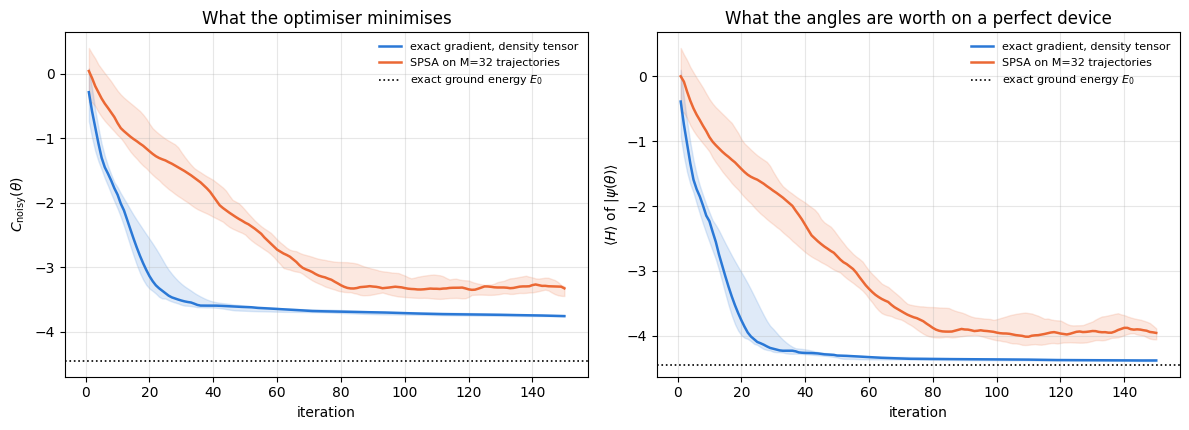

In [14]:
# ==============================================================================
# STEP 9: exact density-tensor gradients vs SPSA on trajectory-estimated costs
# ==============================================================================
# PARAMETERS
R_TRAIN, N_STEPS, LR = 12, 150, 0.05
M_TRAJ = 32                                   # trajectories per cost evaluation of the stochastic method
C_SPSA, GAMMA_SPSA = 0.2, 0.101

P1_DEF = P1_RATIO * P2_DEF
cost_noisy = jax.jit(lambda t: energy_dm(TERMS, noisy_hea_dm(t, N_Q, L_DEF, P1_DEF, P2_DEF)))
cost_ideal = jax.jit(lambda t: energy(TERMS, hardware_efficient_ansatz(t, N_Q, L_DEF)))
monitor_both = lambda t: jnp.stack([cost_noisy(t), cost_ideal(t)])


def cost_traj(key, theta, M=M_TRAJ):
    """Trajectory estimate of the noisy energy: mean over M independent unravellings (unbiased, error ~ 1/sqrt(M))."""
    ks = jax.random.split(key, M)
    return jnp.mean(jax.vmap(lambda k: energy(TERMS, noisy_hea_mcwf(k, theta, N_Q, L_DEF, P1_DEF, P2_DEF)))(ks))


def grad_spsa_traj(c=C_SPSA, gamma=GAMMA_SPSA):
    """SPSA gradient rule (notebook 41, Eq. 12) evaluated on the trajectory cost -- 2 estimates per iteration."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        kd, kp, km = jax.random.split(key, 3)
        delta = jax.random.rademacher(kd, theta.shape).astype(theta.dtype)
        return (cost_traj(kp, theta + c_k * delta) - cost_traj(km, theta - c_k * delta)) / (2 * c_k) * delta
    return rule


th_tr, ks_tr = random_starts(R_TRAIN, n_par_def, seed=42)
METHODS = (("exact gradient, density tensor", lambda t, k, i: jax.grad(cost_noisy)(t)),
           (f"SPSA on M={M_TRAJ} trajectories", grad_spsa_traj()))
hist_train, theta_train = {}, {}
for name, rule in METHODS:
    (thf, h), t_c, t_r = compile_then_run(
        jax.vmap(lambda t, k: train(t, k, rule, opt_adam(LR), monitor_both, N_STEPS)), th_tr, ks_tr)
    theta_train[name] = thf
    hist_train[name] = np.asarray(h)                      # (runs, steps, 2): [noisy cost, noiseless cost]
    print(f"{name:34s} compile {t_c:5.1f} s, run {t_r:5.1f} s   "
          f"final noisy E: median {np.median(hist_train[name][:, -1, 0]):+.5f}, "
          f"best {np.min(hist_train[name][:, -1, 0]):+.5f}")

# Is the Adam step of the SPSA run a fair choice?  Bracket it by a factor of two on either side.
for lr_try in (LR / 2, 2 * LR):
    _, h_try = jax.jit(jax.vmap(lambda t, k: train(t, k, grad_spsa_traj(), opt_adam(lr_try), monitor_both,
                                                   N_STEPS)))(th_tr, ks_tr)
    print(f"  SPSA control with Adam step {lr_try:.3f}: final noisy E median {np.median(np.asarray(h_try)[:, -1, 0]):+.5f}")

h_ex = hist_train["exact gradient, density tensor"]
print(f"  exact-gradient run, median noisy cost at iterations 40 / 150: {np.median(h_ex[:, 39, 0]):+.4f} / "
      f"{np.median(h_ex[:, -1, 0]):+.4f};  median gap noiseless - noisy at iterations 1 / 40 / 150: "
      + " / ".join(f"{np.median(h_ex[:, i, 1] - h_ex[:, i, 0]):+.3f}" for i in (0, 39, N_STEPS - 1)))
print(f"\nreference values:  exact ground energy E0 = {E0_EXACT:+.5f}")
print(f"{'method':>34s} {'median E_noisy':>15s} {'median E_ideal(theta*)':>23s} {'best E_ideal(theta*)':>21s}")
for name, _ in METHODS:
    h = hist_train[name]
    print(f"{name:>34s} {np.median(h[:, -1, 0]):15.5f} {np.median(h[:, -1, 1]):23.5f} {np.min(h[:, -1, 1]):21.5f}")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
it = np.arange(1, N_STEPS + 1)
for j, (name, _) in enumerate(METHODS):
    for col, ax, lab in ((0, axes[0], "noisy cost"), (1, axes[1], "noiseless energy of the same angles")):
        lo, med, hi = bands(hist_train[name][:, :, col])
        ax.fill_between(it, lo, hi, color=PALETTE[j], alpha=0.15)
        ax.plot(it, med, "-", lw=1.8, color=PALETTE[j], label=name)
axes[0].set_ylabel(r"$C_{\mathrm{noisy}}(\theta)$"); axes[0].set_title("What the optimiser minimises")
axes[1].set_ylabel(r"$\langle H\rangle$ of $\vert\psi(\theta)\rangle$")
axes[1].set_title("What the angles are worth on a perfect device")
for ax in axes:
    ax.axhline(E0_EXACT, color="k", ls=":", lw=1.2, label="exact ground energy $E_0$")
    ax.set_xlabel("iteration"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

In [15]:
# ==============================================================================
# CHECKPOINT 3: the trained state, measured on the density tensor and with trajectories
# ==============================================================================
theta_star = theta_train["exact gradient, density tensor"][
    int(np.argmin(hist_train["exact gradient, density tensor"][:, -1, 0]))]
E_dm_star = float(cost_noisy(theta_star))
samples_star = np.asarray(jax.block_until_ready(jax.jit(jax.vmap(
    lambda k: energy(TERMS, noisy_hea_mcwf(k, theta_star, N_Q, L_DEF, P1_DEF, P2_DEF))))(
    jax.random.split(jax.random.PRNGKey(99), 4000))))
E_mc_star, se_star = mean_and_se(samples_star)
print("energy of the best trained noisy state:")
print(f"  density tensor          {E_dm_star:+.6f}")
print(f"  4000 trajectories       {E_mc_star:+.6f} +- {se_star:.6f}   "
      f"({abs(E_mc_star - E_dm_star) / se_star:.2f} standard errors)")
print(f"  noiseless at the same angles {float(cost_ideal(theta_star)):+.6f}")
print(f"  exact ground energy          {E0_EXACT:+.6f}")
assert abs(E_mc_star - E_dm_star) < 5 * se_star
E_bug_star = float(energy_dm(TERMS, noisy_hea_dm(theta_star, N_Q, L_DEF, P1_DEF, P2_DEF, cz_both=False)))
print(f"  wrong control (channel on one qubit of each CZ) {E_bug_star:+.6f}   "
      f"({abs(E_mc_star - E_bug_star) / se_star:.1f} standard errors)")
assert abs(E_mc_star - E_bug_star) > 5 * se_star

energy of the best trained noisy state:
  density tensor          -3.778441
  4000 trajectories       -3.781179 +- 0.020859   (0.13 standard errors)


  noiseless at the same angles -4.361681
  exact ground energy          -4.454849


  wrong control (channel on one qubit of each CZ) -4.027122   (11.8 standard errors)


The two panels separate two things that are easy to conflate.

**Left: the optimiser works.** Both methods reduce the noisy cost. The exact-gradient run reaches a median of
$-3.758$; most of the descent happens in the first 40 iterations, after which the median still falls by $0.16$. The
SPSA run reaches $-3.327$ after 150 iterations with $M=32$ trajectories per evaluation and is still improving. Its
Adam step was not tuned separately; halving it gives the same median to within $0.003$ and doubling it a clearly
worse one ($-3.00$), so $0.05$ is close to the best step for this budget. The stochastic method is slower per iteration, as it was in notebook 41: two noisy scalars per step
against $n=24$ exact derivatives. Its interquartile band is also much wider, because the noise of the estimate is
inherited by the path the optimiser takes. (The exact gradient is a simulator privilege; on a device it would cost
$2n=48$ shot-limited circuit evaluations per iteration, so the two columns do not compare equal budgets.)

**Right: the noisy cost is not the physics.** The same angles, evaluated on a perfect device, give a median energy of
$-4.382$ for the exact-gradient run against the exact ground energy $E_0=-4.4548$ — a far better number than the
$-3.758$ the noisy device reports. The gap between the two panels opens during the first tens of iterations, from
$0.08$ at the random start to about $0.63$, because a state with large energy contrast loses more of it to the
contraction, and then stays there. Reporting the noisy cost as "the variational energy" would understate the quality
of the state found by about $0.62$ in units where the answer is $-4.45$.

The checkpoint confirms once more that the two simulators describe the same state: at the angles that minimised the
noisy cost, the trajectory estimate $-3.7812\pm0.0209$ agrees with the exact density-tensor value $-3.7784$ within
$0.13$ standard errors, while the one-sided-channel model is rejected at $12$ standard errors.

> **Numerical practice.** The variational bound survives noise, but it loses its use. $C(\boldsymbol\theta)\ge E_0$
> holds for the noisy cost too, since $\mathrm{Tr}(\hat H\rho)\ge E_0$ for any state $\rho$. The bound is far from
> tight, and a noisy energy above $E_0$ says nothing about how close the prepared state is to the ground state.

## 10. Optimal-parameter resilience

Section 6 proved that for global depolarising noise the minimiser does not move; Section 7 showed that for local
noise it does, by an amount of order $p$. Sharma, Khatri, Cerezo and Coles (2020) proved resilience statements for
several noise models in variational *compiling* and gave the effect its name — **optimal parameter resilience**. For
local noise and an energy cost the question is quantitative: how much noiseless energy does the move cost?

The experiment is the one the name suggests. **Train under noise, then evaluate the parameters found on a noiseless
simulator.** Two channels are compared at five noise strengths each: the depolarising channel and the
amplitude-damping channel, placed as in Section 4.1. The same strength number does not mean the same error rate: by
the process-fidelity formula of Section 3.2, damping of strength $\gamma$ on one qubit has
$F_e=(1+\sqrt{1-\gamma})^2/4$ and error per gate $r\simeq\gamma/3$, half the $2p/3$ of depolarising noise. The training
uses the same eight random starts at every noise level, so the noiseless energy reached from a given start can be
compared with the one reached from the same start without noise, a **paired** difference. Because the noise strength
is a traced argument, the whole $5\times8$ grid of (noise level, random start) is one compiled program per channel.

depolarising         trained at 5 noise levels x 8 starts: compile 3.0 s, run 2.6 s


amplitude damping    trained at 5 noise levels x 8 starts: compile 2.6 s, run 2.7 s

best noiseless optimum of this ansatz: E = -4.438405   (exact E0 = -4.454849)
                         channel  strength  E_noisy median  E_ideal(theta*) median       best  penalty vs best
                    depolarising     0.000        -4.41346                -4.41346   -4.43840         +0.00000
                                     0.010        -4.06753                -4.40613   -4.43568         +0.00273
                                     0.020        -3.77057                -4.38693   -4.41919         +0.01921
                                     0.040        -3.26147                -4.35831   -4.40455         +0.03385
                                     0.080        -2.45130                -4.34607   -4.39662         +0.04179
               amplitude damping     0.000        -4.41346                -4.41346   -4.43840         +0.00000
                                     0.010        -4.20085  

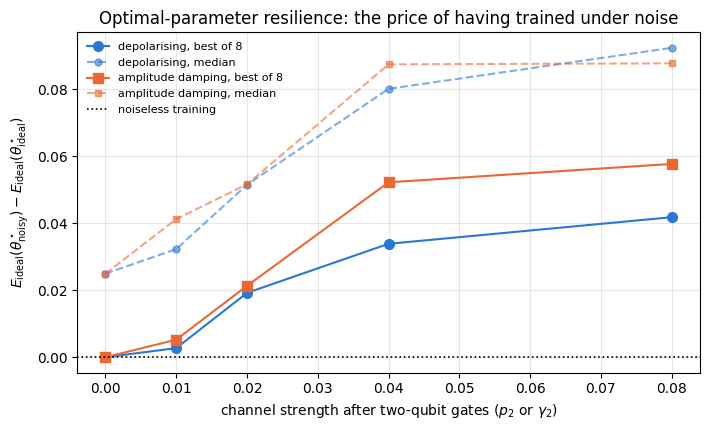

In [16]:
# ==============================================================================
# STEP 10: train noisy, evaluate noiseless -- for a unital and a non-unital channel
# ==============================================================================
import math

# PARAMETERS
R_RES, N_STEPS_RES = 8, 150
P_RES = jnp.asarray([0.0, 0.01, 0.02, 0.04, 0.08])

th_res, ks_res = random_starts(R_RES, n_par_def, seed=1234)


def train_over_noise(chan):
    """Train at every noise level of P_RES from every start of th_res; record (noisy cost, noiseless energy)."""
    def one(p, t, k):
        cn = lambda th: energy_dm(TERMS, noisy_hea_dm(th, N_Q, L_DEF, P1_RATIO * p, p, chan, chan))
        mon = lambda th: jnp.stack([cn(th), cost_ideal(th)])
        return train(t, k, lambda th, kk, i: jax.grad(cn)(th), opt_adam(LR), mon, N_STEPS_RES)[1]
    return compile_then_run(jax.vmap(lambda p: jax.vmap(lambda t, k: one(p, t, k))(th_res, ks_res)), P_RES)


def sign_test_p(n_pos, n):
    """Two-sided sign test: probability of a split at least as uneven as n_pos : n - n_pos if + and - were equally likely."""
    k = max(n_pos, n - n_pos)
    return min(1.0, 2 * sum(math.comb(n, i) for i in range(k, n + 1)) / 2 ** n)


res = {}
for name, chan in (("depolarising", kraus_depolarizing), ("amplitude damping", kraus_amplitude_damping)):
    out, t_c, t_r = train_over_noise(chan)
    res[name] = np.asarray(out)                                              # (n_p, runs, steps, 2)
    print(f"{name:20s} trained at {P_RES.size} noise levels x {R_RES} starts: compile {t_c:.1f} s, run {t_r:.1f} s")

E_ref_ideal = float(np.min(res["depolarising"][0, :, -1, 1]))      # best noiseless optimum found
print(f"\nbest noiseless optimum of this ansatz: E = {E_ref_ideal:.6f}   (exact E0 = {E0_EXACT:.6f})")
print(f"{'channel':>32s} {'strength':>9s} {'E_noisy median':>15s} {'E_ideal(theta*) median':>23s} "
      f"{'best':>10s} {'penalty vs best':>16s}")
for name in res:
    for j, p in enumerate(np.asarray(P_RES)):
        H = res[name][j]
        print(f"{name if j == 0 else '':>32s} {p:9.3f} {np.median(H[:, -1, 0]):15.5f} "
              f"{np.median(H[:, -1, 1]):23.5f} {np.min(H[:, -1, 1]):10.5f} "
              f"{np.min(H[:, -1, 1]) - E_ref_ideal:+16.5f}")

print("\npaired penalty E_ideal(theta*_p) - E_ideal(theta*_0) from the SAME start; convergence diagnostic = median"
      " |change of the noisy cost over the last 50 iterations|")
print(f"{'channel':>20s} {'strength':>9s} {'median paired':>14s} {'# > 0':>6s} {'sign-test p':>12s} {'last-50 change':>15s}")
for name in res:
    for j, p in enumerate(np.asarray(P_RES)[1:], start=1):
        d = res[name][j, :, -1, 1] - res[name][0, :, -1, 1]
        npos = int(np.sum(d > 0))
        drift = np.median(np.abs(res[name][j, :, -1, 0] - res[name][j, :, -51, 0]))
        print(f"{name if j == 1 else '':>20s} {p:9.3f} {np.median(d):+14.4f} {npos:3d}/{R_RES} "
              f"{sign_test_p(npos, R_RES):12.3f} {drift:15.4f}")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
for j, name in enumerate(res):
    best = [np.min(res[name][i, :, -1, 1]) - E_ref_ideal for i in range(P_RES.size)]
    med = [np.median(res[name][i, :, -1, 1]) - E_ref_ideal for i in range(P_RES.size)]
    ax.plot(np.asarray(P_RES), best, MARKERS[j] + "-", ms=7, color=PALETTE[j], label=f"{name}, best of {R_RES}")
    ax.plot(np.asarray(P_RES), med, MARKERS[j] + "--", ms=5, color=PALETTE[j], alpha=0.6, label=f"{name}, median")
ax.axhline(0.0, color="k", ls=":", lw=1.2, label="noiseless training")
ax.set_xlabel(r"channel strength after two-qubit gates ($p_2$ or $\gamma_2$)")
ax.set_ylabel(r"$E_{\mathrm{ideal}}(\theta^\star_{\mathrm{noisy}})-E_{\mathrm{ideal}}(\theta^\star_{\mathrm{ideal}})$")
ax.set_title("Optimal-parameter resilience: the price of having trained under noise")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

Read the "best" column first. Training at $p_2=0.08$, an error rate at which the noisy device reports a median energy
of $-2.451$ instead of about $-4.41$, still yields angles whose best *noiseless* energy is $-4.3966$, $0.042$ above
the best noiseless optimum $-4.4384$ found by the same eight runs. At $p_2=0.01$ the best-of-eight penalty is
$2.7\cdot10^{-3}$, about a hundred times smaller than the $0.35$ by which the median reported energy is wrong.

Best-of-eight is a fragile statistic, and the paired table is the more reliable one. At strength $0.01$ the paired
penalties have both signs (six and four of eight positive, sign-test $p=0.29$ and $1$): the shift of the minimum is
smaller than the run-to-run differences of the optimisation itself and is not resolved. From $0.02$ upwards the
penalty is positive in seven or eight of eight starts (sign-test $p=0.07$ and $0.008$) and grows with the noise, to
medians of $0.04$–$0.07$ at strengths $0.04$–$0.08$. The two
channels are not distinguished by these data: their paired medians cross from one strength to the next, and at
equal strength damping has half the error per gate of depolarising noise. The last column is a warning: under strong
damping the noisy cost is still changing at the end of the 150 iterations (by $0.41$ over the last 50 at strength
$0.08$), so these runs measure the outcome of a
fixed training budget; they do not locate the noisy minimum.

The penalties stay small compared with the error of the reported energy because the cost is quadratic in the
displacement of the minimiser, and because Section 7.2 found very soft directions in the Hessian, along which a
displacement costs little energy. The summary of these numbers is: **the parameters are far more robust than the
cost value**, and the useful output of a noisy variational run is the parameter vector rather than the energy it
reported.

> **Common pitfall.** This conclusion is a measurement on one Hamiltonian, one ansatz and two channels, at
> $N=4$, with a fixed training budget. It is not a theorem. What *is* a theorem is Section 6: for global depolarising
> noise the optimum is exactly unchanged. For local noise the optimum moves (Section 7.2), and how much that costs has
> to be measured.

## 11. The depth trade-off

Notebook 41 measured that on a *noiseless* simulator more layers are better: extra parameters raise the success rate
and lower the achievable floor. Sections 5 and 8 measured that on a *noisy* device every extra layer contracts the
cost, and its gradients, further towards the maximally mixed value. The two effects pull in opposite directions, so
the reported energy has an optimum in depth, and that optimum should move to smaller depth as the error rate grows.

The experiment trains the ansatz at depths $L=1,\dots,6$ and five noise strengths from $0$ to $0.02$, with eight
random starts each, 150 Adam iterations per run, and records the best noisy energy reached — the number the device
would report. Depth is a static quantity (it is the length of the `lax.scan`), so one program is compiled per depth;
the noise axis is vmapped inside it.

best noisy energy over 8 random starts (compilation 18.7 s, run 25.7 s); exact E0 = -4.45485
  L     n       p2=0  p2=0.0005   p2=0.002   p2=0.008    p2=0.02
  1    16    -4.3760    -4.3670    -4.3402    -4.2342    -4.0294
  2    24    -4.4406    -4.4191    -4.3562    -4.1527    -3.7991
  3    32    -4.4391    -4.4114    -4.3315    -4.0724    -3.6156
  4    40    -4.4442    -4.4040    -4.3075    -3.9695    -3.4348
  5    48    -4.4534    -4.4101    -4.2882    -3.8886    -3.2501
  6    56    -4.4545    -4.3943    -4.2532    -3.7923    -3.1249

optimal depth for each error rate:
  p2 = 0.0000  ->  L* = 6   (best energy -4.4545)
  p2 = 0.0005  ->  L* = 2   (best energy -4.4191)
  p2 = 0.0020  ->  L* = 2   (best energy -4.3562)
  p2 = 0.0080  ->  L* = 1   (best energy -4.2342)
  p2 = 0.0200  ->  L* = 1   (best energy -4.0294)

the two competing terms:
  L  noiseless error E-E0   noise penalty at p2=0.02
  1             7.883e-02                      0.347
  2             1.421e-02         

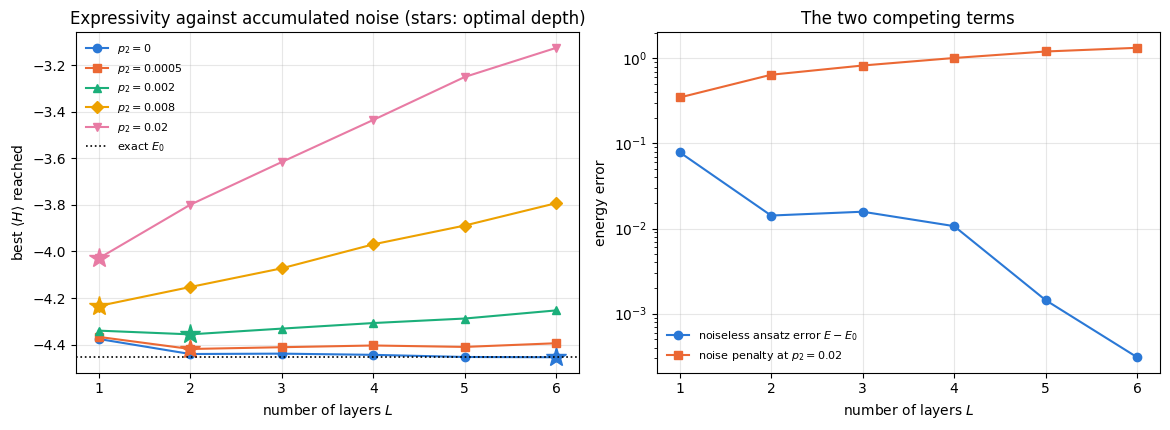

In [17]:
# ==============================================================================
# STEP 11: best achievable noisy energy against depth, for several error rates
# ==============================================================================
# PARAMETERS
DEPTHS_TO = (1, 2, 3, 4, 5, 6)
P_TO = jnp.asarray([0.0, 0.0005, 0.002, 0.008, 0.02])
R_TO, N_STEPS_TO = 8, 150

best_E = np.zeros((len(DEPTHS_TO), P_TO.size))
med_E = np.zeros_like(best_E)
ideal_floor = np.zeros(len(DEPTHS_TO))
t_comp_to = t_run_to = 0.0
for iL, L in enumerate(DEPTHS_TO):
    n_par = hea_num_params(N_Q, L)
    th_to, ks_to = random_starts(R_TO, n_par, seed=77)

    def one(p, t, k, L=L):
        cn = lambda th: energy_dm(TERMS, noisy_hea_dm(th, N_Q, L, P1_RATIO * p, p))
        ci = lambda th: energy(TERMS, hardware_efficient_ansatz(th, N_Q, L))
        return train(t, k, lambda th, kk, i: jax.grad(cn)(th), opt_adam(LR),
                     lambda th: jnp.stack([cn(th), ci(th)]), N_STEPS_TO)[1]

    Hh, t_c, t_r = compile_then_run(jax.vmap(lambda p: jax.vmap(lambda t, k: one(p, t, k))(th_to, ks_to)), P_TO)
    Hh = np.asarray(Hh)
    t_comp_to, t_run_to = t_comp_to + t_c, t_run_to + t_r
    best_E[iL] = Hh[:, :, -1, 0].min(axis=1)
    med_E[iL] = np.median(Hh[:, :, -1, 0], axis=1)
    ideal_floor[iL] = Hh[0, :, -1, 1].min()

print(f"best noisy energy over {R_TO} random starts (compilation {t_comp_to:.1f} s, run {t_run_to:.1f} s); "
      f"exact E0 = {E0_EXACT:.5f}")
print(f"{'L':>3s} {'n':>5s} " + " ".join(f"{('p2=' + f'{float(p):g}'):>10s}" for p in P_TO))
for iL, L in enumerate(DEPTHS_TO):
    print(f"{L:3d} {hea_num_params(N_Q, L):5d} " + " ".join(f"{best_E[iL, j]:10.4f}" for j in range(P_TO.size)))
print("\noptimal depth for each error rate:")
for j, p in enumerate(np.asarray(P_TO)):
    L_star = DEPTHS_TO[int(np.argmin(best_E[:, j]))]
    print(f"  p2 = {p:.4f}  ->  L* = {L_star}   (best energy {best_E[:, j].min():+.4f})")
print("\nthe two competing terms:")
print(f"{'L':>3s} {'noiseless error E-E0':>21s} {'noise penalty at p2=' + f'{float(P_TO[-1]):g}':>26s}")
for iL, L in enumerate(DEPTHS_TO):
    print(f"{L:3d} {ideal_floor[iL] - E0_EXACT:21.3e} {best_E[iL, -1] - ideal_floor[iL]:26.3f}")
print(f"  noiseless error falls by a factor {(ideal_floor[0] - E0_EXACT) / (ideal_floor[-1] - E0_EXACT):.0f} "
      f"between L = {DEPTHS_TO[0]} and L = {DEPTHS_TO[-1]}")

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
for j, p in enumerate(np.asarray(P_TO)):
    axes[0].plot(DEPTHS_TO, best_E[:, j], MARKERS[j % len(MARKERS)] + "-", ms=6, color=PALETTE[j],
                 label=f"$p_2={p:g}$")
    k = int(np.argmin(best_E[:, j]))
    axes[0].plot([DEPTHS_TO[k]], [best_E[k, j]], "*", ms=15, color=PALETTE[j])
axes[0].axhline(E0_EXACT, color="k", ls=":", lw=1.2, label="exact $E_0$")
axes[0].set_xlabel("number of layers $L$"); axes[0].set_ylabel(r"best $\langle H\rangle$ reached")
axes[0].set_title("Expressivity against accumulated noise (stars: optimal depth)")
axes[0].legend(fontsize=8)

axes[1].plot(DEPTHS_TO, ideal_floor - E0_EXACT, MARKERS[0] + "-", ms=6, color=PALETTE[0],
             label="noiseless ansatz error $E-E_0$")
axes[1].plot(DEPTHS_TO, best_E[:, -1] - ideal_floor, MARKERS[1] + "-", ms=6, color=PALETTE[1],
             label=f"noise penalty at $p_2={float(P_TO[-1]):g}$")
axes[1].set_yscale("log")
axes[1].set_xlabel("number of layers $L$"); axes[1].set_ylabel("energy error")
axes[1].set_title("The two competing terms"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The optimum exists and it moves to smaller depth as the noise grows.

* On a **perfect** device ($p_2=0$) the best energy falls from $-4.376$ at $L=1$ to $-4.4545$ at $L=6$, within
  $3\cdot10^{-4}$ of $E_0$, but not monotonically: $L=3$ ($-4.4391$) ends above $L=2$ ($-4.4406$). That inversion
  belongs to the training budget of 150 constant-step Adam iterations from eight starts; every entry of the table is
  the best energy found within that budget.
* At $p_2=5\cdot10^{-4}$ the optimum is already at $L=2$. In the dictionary of Section 3.2 this model has a two-qubit
  error per gate $r_2=\tfrac45[1-(1-p_2)^2]=8.0\cdot10^{-4}$. The margin to the next depth is small ($-4.4191$ at
  $L=2$ against $-4.4114$ at $L=3$), smaller than the effects of the training budget just mentioned.
* At $p_2=2\cdot10^{-3}$ the optimum is $L=2$ by a wider margin; at $p_2=8\cdot10^{-3}$ and $p_2=2\cdot10^{-2}$
  it has dropped to $L=1$, the shallowest circuit in the study.

The right panel shows the two terms whose sum produces the optimum. The noiseless ansatz error falls steeply with
depth — from $7.883\cdot10^{-2}$ at $L=1$ to $3.073\cdot10^{-4}$ at $L=6$, a factor of $257$, with the same
non-monotonic step at $L=3$ — while the noise penalty at $p_2=0.02$ grows from $0.347$ to $1.330$. The first curve
falls as the ansatz becomes able to represent the ground state; the second rises with every layer. Where the first
stops falling faster than the second rises, the sum turns around.

> **Physics insight.** This trade-off is a central design constraint for noisy devices. A circuit that is deep
> enough to represent the target accumulates noise at every layer, and the accumulated error stays small only while
> the error per gate is below roughly one over the number of gates. With a different ansatz or Hamiltonian the
> numbers change, since the ansatz error depends on the target state; the competition between the two terms remains.

## 12. Zero-noise extrapolation

Error *correction* removes errors by encoding one logical qubit in many physical ones, and needs resources no current
device has. Error *mitigation* leaves the errors in place and corrects the **estimate** afterwards, by running the
circuit at several noise levels and extrapolating. The idea is due to Temme, Bravyi and Gambetta (2017) and,
independently, Li and Benjamin (2017).

### 12.1 The method

Let $E(s)$ be the expectation value measured when every channel strength is multiplied by a factor $s\ge1$ (we write
$s$ rather than $\lambda$, which is already the Bloch contraction factor). Under mild assumptions $E(s)$ is smooth
and $E(0)$ is the noiseless value we want but cannot measure: on hardware $s$ can be raised (by stretching pulses, or
by replacing each gate $G$ by $GG^\dagger G$, the same unitary with roughly three times the error, exactly so only if
$G^\dagger$ is as noisy as $G$ and the errors add) but not lowered. **Extrapolate to $s=0$.** With
$s_1<\dots<s_m$ and the corresponding measurements, fit a polynomial of degree $m-1$ and evaluate it at zero. This
is Richardson extrapolation, and the result is the linear combination

$$\hat E(0)=\sum_{i=1}^{m}c_i\,E(s_i),\qquad
  c_i=\prod_{j\neq i}\frac{s_j}{s_j-s_i},\qquad \sum_ic_i=1,\tag{17}$$

which follows from writing the Lagrange interpolating polynomial through the points $(s_i,E(s_i))$ and evaluating it
at $s=0$ (Numerical Recipes, §3.2; the same idea, with the step size in place of $s$, is Romberg integration, §4.3). For $m=2$ with $s=1,2$ this is $\hat E(0)=2E(1)-E(2)$, ordinary linear extrapolation.

### 12.2 Bias, variance, and when it stops working

Expand the noisy expectation value in the noise strength: with base error probability $p$,
$E(s)=E_0+a_1(sp)+a_2(sp)^2+\dots$ The degree-$(m-1)$ Richardson combination annihilates the terms of order
$1,\dots,m-1$ exactly (because $\sum_ic_is_i^k=0$ for $1\le k\le m-1$) and leaves a **bias** of order $p^m$. So
mitigation helps when the series converges quickly, that is when $s_m\times$ (total error probability of the
circuit) is small; it fails when the higher-order terms are not small.

The price is **variance**. If each $E(s_i)$ is estimated from $M$ shots with single-shot variance $\sigma^2$, the
mitigated estimate has variance $\sigma^2\sum_ic_i^2/M$. The coefficients alternate in sign and grow with $m$: for
$s=1,2,3$ the combination $3E(1)-3E(2)+E(3)$ has $\sum_ic_i^2=19$, so it needs $19$ times the shots per noise level,
$57$ times the shots in total, to match the statistical error of one unmitigated measurement. **Mitigation trades bias
for variance**, and both halves of that trade must be quoted. For a deep circuit the trade worsens exponentially: the
signal $E(s)-\mathrm{Tr}\hat H/2^N$ is attenuated roughly like $e^{-\kappa sG p}$ for $G$ noisy gates and a constant
$\kappa$ of order one (Eq. (9)), and recovering it costs the inverse square of that attenuation in shots.

Richardson coefficients of Eq. (17)
  m = 2: c = [ 2. -1.]   sum 1.000000   noise amplification sqrt(sum c^2) = 2.236   total shots / unmitigated = m sum c^2 = 10
  m = 3: c = [ 3. -3.  1.]   sum 1.000000   noise amplification sqrt(sum c^2) = 4.359   total shots / unmitigated = m sum c^2 = 57
  m = 4: c = [ 4. -6.  4. -1.]   sum 1.000000   noise amplification sqrt(sum c^2) = 8.307   total shots / unmitigated = m sum c^2 = 276

zero-noise extrapolation at the trained angles; the target is the noiseless value -4.361681
  base p2      E(s=1)        E(2)        E(3)  linear (m=2)  Richardson (m=3)   |err| lin  |err| Rich


   0.0025    -4.28435    -4.20832    -4.13359      -4.36037          -4.36166    1.31e-03    2.17e-05


   0.0050    -4.20832    -4.06011    -3.91687      -4.35654          -4.36151    5.14e-03    1.70e-04


   0.0100    -4.06011    -3.77844    -3.51538      -4.34178          -4.36039    1.99e-02    1.29e-03


   0.0200    -3.77844    -3.26972    -2.82614      -4.28716          -4.35231    7.45e-02    9.37e-03


   0.0400    -3.26972    -2.43950    -1.80920      -4.09994          -4.29985    2.62e-01    6.18e-02


   0.0800    -2.43950    -1.33157    -0.69885      -3.54744          -4.02265    8.14e-01    3.39e-01


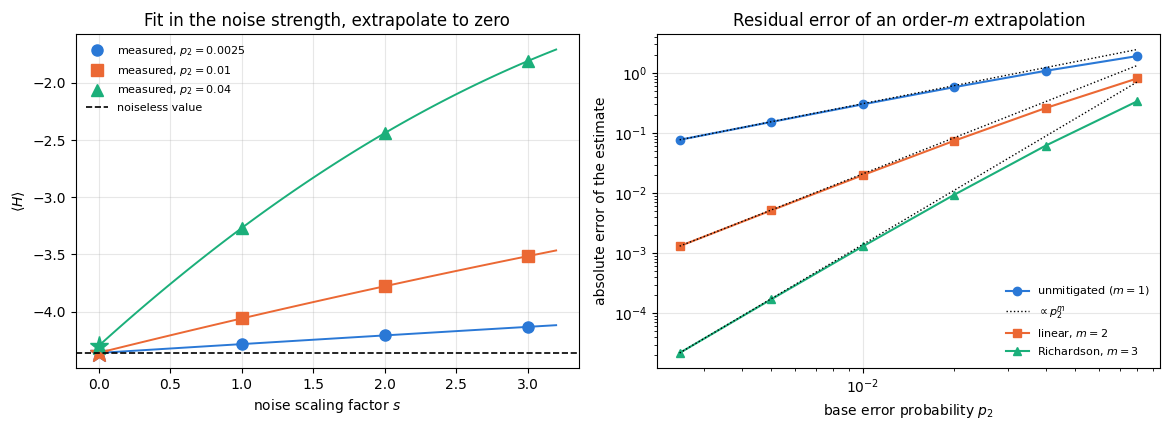

In [18]:
# ==============================================================================
# STEP 12: Richardson extrapolation of the noisy energy in the noise scaling factor
# ==============================================================================
LAMBDAS = np.array([1.0, 2.0, 3.0])            # the noise scale factors s_i of Eq. (17)


def richardson_weights(lams):
    """Coefficients c_i of Eq. (17): the Lagrange polynomial through (s_i, E_i), evaluated at s = 0 (lams = s_i)."""
    lams = np.asarray(lams, dtype=float)
    return np.array([np.prod([lams[j] / (lams[j] - lams[i]) for j in range(lams.size) if j != i])
                     for i in range(lams.size)])


print("Richardson coefficients of Eq. (17)")
for m in (2, 3, 4):
    c = richardson_weights(LAMBDAS[:m] if m <= 3 else np.arange(1.0, m + 1))
    print(f"  m = {m}: c = {np.round(c, 4)}   sum {c.sum():.6f}   noise amplification "
          f"sqrt(sum c^2) = {np.sqrt((c ** 2).sum()):.3f}   total shots / unmitigated = m sum c^2 = "
          f"{m * (c ** 2).sum():.0f}")

E_exact_star = float(cost_ideal(theta_star))
print(f"\nzero-noise extrapolation at the trained angles; the target is the noiseless value {E_exact_star:+.6f}")
print(f"{'base p2':>9s} {'E(s=1)':>11s} {'E(2)':>11s} {'E(3)':>11s} "
      f"{'linear (m=2)':>13s} {'Richardson (m=3)':>17s} {'|err| lin':>11s} {'|err| Rich':>11s}")
zne_rows = []
for base in (0.0025, 0.005, 0.01, 0.02, 0.04, 0.08):
    f_base = jax.jit(lambda t, s, b=base: energy_dm(TERMS, noisy_hea_dm(t, N_Q, L_DEF, P1_RATIO * b * s, b * s)))
    ys = np.array([float(f_base(theta_star, lam)) for lam in LAMBDAS])
    lin = float(richardson_weights(LAMBDAS[:2]) @ ys[:2])
    rich = float(richardson_weights(LAMBDAS) @ ys)
    zne_rows.append((base, ys, lin, rich))
    print(f"{base:9.4f} {ys[0]:11.5f} {ys[1]:11.5f} {ys[2]:11.5f} {lin:13.5f} {rich:17.5f} "
          f"{abs(lin - E_exact_star):11.2e} {abs(rich - E_exact_star):11.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
lam_fine = np.linspace(0, 3.2, 100)
for j, (base, ys, lin, rich) in enumerate(zne_rows[::2]):
    c = PALETTE[j]
    axes[0].plot(LAMBDAS, ys, MARKERS[j] + "", ms=8, color=c, label=f"measured, $p_2={base:g}$")
    axes[0].plot(lam_fine, np.polyval(np.polyfit(LAMBDAS, ys, 2), lam_fine), "-", lw=1.4, color=c)
    axes[0].plot([0.0], [rich], "*", ms=14, color=c)
axes[0].axhline(E_exact_star, color="k", ls="--", lw=1.2, label="noiseless value")
axes[0].set_xlabel(r"noise scaling factor $s$"); axes[0].set_ylabel(r"$\langle H\rangle$")
axes[0].set_title("Fit in the noise strength, extrapolate to zero"); axes[0].legend(fontsize=8)

bases = np.array([r[0] for r in zne_rows])
series = [("unmitigated ($m=1$)", [abs(r[1][0] - E_exact_star) for r in zne_rows], 1),
          ("linear, $m=2$", [abs(r[2] - E_exact_star) for r in zne_rows], 2),
          ("Richardson, $m=3$", [abs(r[3] - E_exact_star) for r in zne_rows], 3)]
for k, (lab, ys_, sl) in enumerate(series):
    axes[1].loglog(bases, ys_, MARKERS[k] + "-", ms=6, color=PALETTE[k], label=lab)
    axes[1].loglog(bases, ys_[0] * (bases / bases[0]) ** sl, "k:", lw=1.0,
                   label=r"$\propto p_2^m$" if k == 0 else None)
axes[1].set_xlabel(r"base error probability $p_2$"); axes[1].set_ylabel("absolute error of the estimate")
axes[1].set_title(r"Residual error of an order-$m$ extrapolation")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The two regimes announced in Section 12.2 are both visible.

**Where it helps.** At $p_2=2.5\cdot10^{-3}$ the raw measurement is wrong by $7.7\cdot10^{-2}$; linear extrapolation
from two points reduces the error to $1.3\cdot10^{-3}$, and the three-point Richardson combination to
$2.2\cdot10^{-5}$ — three and a half orders of magnitude of bias removed, for the price of two extra noise levels
and, at equal statistical error, $57$ times the shots of one unmitigated measurement. The right panel shows why the
bias falls so fast: the unmitigated error is linear in $p_2$, the two-point estimate quadratic and the three-point
estimate cubic. Each measured curve stays within $16\%$ of the dotted reference line of its own order from
$p_2=2.5\cdot10^{-3}$ to $2\cdot10^{-2}$, and bends below it at larger $p_2$, where the higher-order terms of the
expansion take over.

**Where it fails.** At $p_2=0.08$ the raw error is $1.9$, the linear estimate is still wrong by $0.81$ and Richardson
by $0.34$. At $s=3$ and $p_2=0.08$ the circuit has an aggregate error probability of order one, the state is close to
maximally mixed — the measured $E(3)=-0.70$ against a noiseless $-4.36$ — and $E(s)$ has flattened out. A function
that has already saturated carries little information about its value at $s=0$, and no polynomial through three of
its points can recover it.

The table of coefficients quantifies the other half of the trade. Going from $m=2$ to $m=4$ raises
$\sqrt{\sum_ic_i^2}$ from $2.24$ to $8.31$: shot noise in the inputs is amplified by that factor, so the shots per
noise level must grow by its square — a factor $14$ — to keep the statistical error where it was. A high-order
extrapolation on a device is therefore a deliberate exchange of bias for variance. On the noise-induced plateau of
Section 8, Wang *et al.* (2021) argue that mitigation acting as an affine map on cost values cannot remove the
exponential scaling, consider it unlikely that post-processing in general can, and leave the general question open;
for extrapolation, the shot cost of Section 12.2, growing exponentially with the number of noisy gates, is where the
difficulty reappears.

> **Numerical practice.** Every number in this section came from *exact* density-tensor evaluations, so the
> statistical half of the trade-off was switched off deliberately in order to expose the bias half cleanly. Exercise 6
> puts the shot noise back.

## 13. Cost: density tensor against trajectories

The two representations scale differently, and the crossover decides which one to use.

* The **density tensor** holds $4^N$ complex numbers and costs $O(2^k4^N)$ per $k$-qubit operation. It is exact, and
  `jax.grad` runs through it, but $N=13$ already needs $4^{13}\times16$ bytes $\approx1.1$ GB per array.
* **Trajectories** hold $2^N$ complex numbers each. $M$ of them cost $O(M\,2^N)$ and carry a statistical error
  $\propto1/\sqrt M$, so *at fixed accuracy* $M$ is fixed and the total cost is $O(M2^N)$ — exponentially cheaper in
  the exponent, at the price of never being exact.

The crossover is where $M\,2^N\approx4^N$, i.e. $2^N\approx M$. The measurement below uses $M=200$, so the prediction
is a crossover near $N=\log_2 200\approx7.6$.

one evaluation of the noisy ansatz, L = 2 layers (run time excludes compilation; 'first' = first call, compilation included)
  N    DM [ms]  DM first [s]    DM memory     MCWF x200 [ms]  MCWF first [s]  ratio DM/MCWF
  2       0.04          0.16       0.2 kB               1.86            0.83           0.02
  3       0.10          0.26       1.0 kB               2.52            0.85           0.04
  4       0.22          0.30       4.0 kB               3.88            1.06           0.06
  5       0.72          0.40      16.0 kB               6.89            1.33           0.10
  6       2.97          0.45      64.0 kB              12.86            1.60           0.23
  7      12.17          0.73     256.0 kB              29.47            2.24           0.41
  8      25.96          0.65       1.0 MB              53.80            2.17           0.48
  9     136.58          1.07       4.0 MB              80.58            2.49           1.70
 10     710.57          1.58      16.0 MB      

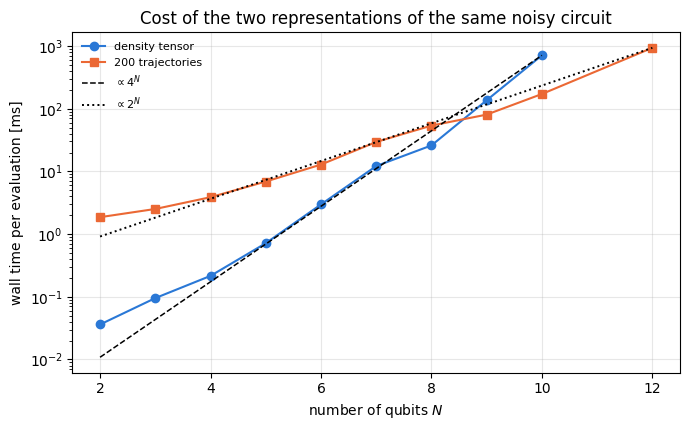

In [19]:
# ==============================================================================
# STEP 13: measured cost of one circuit evaluation, density tensor vs M trajectories
# ==============================================================================
M_COST, L_COST = 200, 2
N_DM = (2, 3, 4, 5, 6, 7, 8, 9, 10)
N_MC = (2, 3, 4, 5, 6, 7, 8, 9, 10, 12)


def make_dm_run(N):
    """A compiled noisy-circuit evaluation on the density tensor for N qubits."""
    th = jax.random.uniform(jax.random.PRNGKey(1), (2 * N * (L_COST + 1),), minval=-jnp.pi, maxval=jnp.pi)
    return jax.jit(lambda: noisy_hea_dm(th, N, L_COST, P1_DEF, P2_DEF))


def make_mc_run(N, M):
    """The same circuit as M quantum trajectories, vmapped over PRNG keys."""
    th = jax.random.uniform(jax.random.PRNGKey(1), (2 * N * (L_COST + 1),), minval=-jnp.pi, maxval=jnp.pi)
    keys = jax.random.split(jax.random.PRNGKey(0), M)
    return jax.jit(lambda: jax.vmap(lambda k: noisy_hea_mcwf(k, th, N, L_COST, P1_DEF, P2_DEF))(keys))


def first_call(fn):
    """Wall time of the first call of a jitted function: tracing + compilation + one run."""
    t0 = time.perf_counter()
    jax.block_until_ready(fn())
    return time.perf_counter() - t0


t_dm, t_mc, c_dm, c_mc = {}, {}, {}, {}
for N in N_DM:
    f = make_dm_run(N)
    c_dm[N] = first_call(f)
    t_dm[N] = timed(f, repeat=5)
for N in N_MC:
    f = make_mc_run(N, M_COST)
    c_mc[N] = first_call(f)
    t_mc[N] = timed(f, repeat=5)
print(f"one evaluation of the noisy ansatz, L = {L_COST} layers (run time excludes compilation; "
      f"'first' = first call, compilation included)")
print(f"{'N':>3s} {'DM [ms]':>10s} {'DM first [s]':>13s} {'DM memory':>12s} {'MCWF x' + str(M_COST) + ' [ms]':>18s} "
      f"{'MCWF first [s]':>15s} {'ratio DM/MCWF':>14s}")
for N in N_MC:
    dm = f"{t_dm[N] * 1e3:10.2f}" if N in t_dm else f"{'-':>10s}"
    dmc = f"{c_dm[N]:13.2f}" if N in c_dm else f"{'-':>13s}"
    mem = 16 * 4 ** N
    mem_s = f"{mem / 1024:.1f} kB" if mem < 1024 ** 2 else f"{mem / 1024 ** 2:.1f} MB"
    ratio = f"{t_dm[N] / t_mc[N]:14.2f}" if N in t_dm else f"{'-':>14s}"
    print(f"{N:3d} {dm} {dmc} {mem_s:>12s} {t_mc[N] * 1e3:18.2f} {c_mc[N]:15.2f} {ratio}")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.semilogy(N_DM, [t_dm[N] * 1e3 for N in N_DM], MARKERS[0] + "-", ms=6, color=PALETTE[0], label="density tensor")
ax.semilogy(N_MC, [t_mc[N] * 1e3 for N in N_MC], MARKERS[1] + "-", ms=6, color=PALETTE[1],
            label=f"{M_COST} trajectories")
ax.semilogy(N_DM, t_dm[N_DM[-1]] * 1e3 * 4.0 ** (np.array(N_DM) - N_DM[-1]), "k--", lw=1.1, label=r"$\propto4^N$")
ax.semilogy(N_MC, t_mc[N_MC[-1]] * 1e3 * 2.0 ** (np.array(N_MC) - N_MC[-1]), "k:", lw=1.4, label=r"$\propto2^N$")
ax.set_xlabel("number of qubits $N$"); ax.set_ylabel("wall time per evaluation [ms]")
ax.set_title("Cost of the two representations of the same noisy circuit")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

Each curve approaches its predicted exponent once the arrays are large enough for the arithmetic to dominate the fixed
overheads: the density tensor steepens towards the $4^N$ reference line, the trajectory batch tracks $2^N$. The
ratio in the last column crosses one between $N=8$ and $N=9$, close to the naive estimate $2^N\approx M$, i.e.
$N\approx7.6$. The remaining difference is a constant factor the estimate ignores: per noise location a trajectory
evaluates all Kraus branches on a small reduced density matrix, draws a random number and renormalises, while the
density tensor performs one contraction per Kraus operator on each side.

Memory adds a second, harder limit. The density tensor is $1$ MB at $N=8$, $16$ MB at $N=10$ and $256$ MB at
$N=12$ — per intermediate array, in a graph that holds several of them and, under `jax.grad`, keeps many more. A
trajectory is $64$ kB at $N=12$, and two hundred of them run in about a second. The first calls in the table, which
include compilation, take between $0.2$ and $4$ s and grow slowly with $N$: the traced graph has one operation per
gate and noise location, a number linear in $N$, while the arrays it acts on grow exponentially.

The decision rule is not only about resources. The density tensor gives an exact number and an exact gradient; the
trajectories give an estimate with an error bar and, in practice, a gradient that has to come from SPSA or parameter
shift. For the small systems of this notebook the density tensor is the right tool, which is why every *theoretical*
statement above was checked on it and the trajectories were used to confirm that the statements survive the
unravelling.

## 14. Key takeaways

* **The conversion from laboratory numbers to channel parameters is a short derivation.** The depolarising channel
  contracts the Bloch vector by $1-4p/3$ and has average gate fidelity $1-2p/3$, so a reported single-qubit error per
  gate $r$ becomes $p=\tfrac32r$; for the model's two-qubit gates $r_2=\tfrac45[1-(1-p_2)^2]\simeq\tfrac85p_2$;
  damping and dephasing follow from $\gamma=1-e^{-t/T_1}$ and $p=\tfrac12(1-e^{-t/T_\varphi})$, with the coherence
  decaying at $1/T_2$. All were confirmed numerically.
* **Two independent simulators agree, and the test has power.** The density tensor and the trajectory unravelling
  gave the same energy of the same noisy variational state within $0.32$ standard errors at $4000$ trajectories,
  while a one-sided-channel model was rejected at $7$ standard errors; the rms error over independent batches
  followed $\sigma_1/\sqrt M$.
* **Local depolarising noise contracts every Pauli expectation value by $\lambda^{wcD}$** with $\lambda=1-4p/3$,
  Eq. (9) — exact to round-off where its assumption holds. In a real circuit the gates change the weights in both
  directions: the amplitude of a landscape slice followed $\lambda^{4.79}$ over $0\le p_2\le0.25$, below the
  two-body count $7.27$, while the gradient variance of Section 8 decayed faster than the same count predicts.
* **Global depolarising noise does not move the minimum.** It contracts every traceless operator by the same factor,
  so $C_{\rm noisy}=(1-q)C+q\,\mathrm{Tr}\hat H/2^N$ — verified grid point by grid point to $10^{-16}$ on an
  $81\times81$ slice; the gradient is rescaled by exactly $1-q$ without rotating.
* **Local noise does move it, unital or not.** For one qubit the optimal angle obeys
  $\tan\theta_\star=1/(h\sqrt{1-\gamma})$ under amplitude damping and $(1-2p)/h$ under dephasing (measured to a third
  of the grid spacing). For the four-qubit circuit local depolarising noise turns the cost into that of a Hamiltonian
  with a rescaled field, Eq. (15a), and the gradient of the noisy cost at the noiseless optimum grows linearly in $p$
  for local depolarising, dephasing and damping noise, while it stays at the noiseless residual for global noise.
* **Noise produces a barren plateau in the circuit depth.** Wang *et al.* bound every gradient component by a factor
  decaying exponentially in $L$ for local Pauli noise. At $N=4$, where the noiseless gradient variance hardly changes
  with depth, the noisy variance fell exponentially, $16$–$25\%$ steeper than the noise-location count of
  Eq. (16), with bootstrap intervals that exclude both Eq. (16) and the weight-1 control.
* **The parameters are more robust than the cost.** Training at an error rate so high that the device reports $-2.451$
  still produced angles worth $-4.397$ on a noiseless simulator, $0.042$ from the best of the same eight runs. Paired
  by start, the penalty is resolved from $p_2\approx0.02$ upwards and reaches a few $10^{-2}$; at $0.01$ it is
  smaller than the run-to-run differences of the optimisation.
* **There is an optimal depth and it shrinks with the error rate.** Measured with a fixed training budget:
  $L^\star=6$ (the largest tried) at $p_2=0$, $L^\star=2$ at $p_2=5\cdot10^{-4}$ and $2\cdot10^{-3}$, $L^\star=1$
  at $8\cdot10^{-3}$ and $2\cdot10^{-2}$; the smallest of these margins is within the reach of the training budget.
* **Zero-noise extrapolation removes bias order by order and costs variance.** Richardson extrapolation from three
  noise levels reduced the error at $p_2=2.5\cdot10^{-3}$ from $7.7\cdot10^{-2}$ to $2.2\cdot10^{-5}$, with residuals
  scaling as $p_2^m$ for $m=1,2,3$, at $57$ times the shots of an unmitigated estimate of equal statistical error; at
  $p_2=0.08$ it left an error of $0.34$, because the observable had already saturated.
* **The crossover between the two simulators lies near $2^N\approx M$.** With $M=200$ trajectories the density
  tensor is faster up to $N=8$ and slower from $N=9$; beyond that, memory ($256$ MB per array at $N=12$ against
  $64$ kB per trajectory) decides as well.

## 15. Exercises

1. ★ **Dephasing instead of depolarising.** Re-run the landscape slice of Section 5.2 with `kraus_dephasing` as both
   channels. Derive the eigenvalues of $\mathcal Z_p^\dagger$ on $X$, $Y$ and $Z$ first — they are not all the
   same. Does the amplitude of the slice still follow a power of a single factor, and how far does the minimum of the
   slice move compared with depolarising noise of the same $p_2$?
2. ★ **The weight dependence, directly.** Fix a depth and a noise strength and measure
   $\langle P\rangle_{\rm noisy}/\langle P\rangle_{\rm ideal}$ for Pauli strings of weight $1,2,3,4$ *through the real
   noisy ansatz*, not the bare noise rounds of Step 3. Plot $\ln$ of the ratio against $w$ and compare its slope with
   $cL\ln\lambda$.
3. ★★ **A global depolarising fit (extend the code).** Many experiments model an entire noisy circuit as one global
   depolarising channel. Fit $q$ by least squares from the noisy and noiseless costs at 50 random
   $\boldsymbol\theta$, then test the model by predicting the noisy cost at 50 fresh ones. How good is the
   single-parameter description at $p_2=0.005$, and at $p_2=0.05$?
4. ★★ **Resilience of the prepared state (physics).** Section 10 measured the energy penalty. Measure instead
   the fidelity $\lvert\langle\psi(\boldsymbol\theta^\star_{\rm noisy})\vert\psi(\boldsymbol\theta^\star_{\rm ideal})\rangle\rvert^2$
   between the two *states* the two optima prepare, for the paired runs of Section 10. How do the infidelity and the
   energy penalty scale with $p_2$, and how is their ratio related to the curvature of the cost and of the fidelity
   (Hessian against metric) along the displacement?
5. ★★ **Noise scaling by gate folding (extend the code).** Replace each $CZ$ by $CZ\,CZ^\dagger\,CZ$ in the gate list
   and add its noise channels; this triples the error of that gate without changing the ideal unitary, which is how
   $\lambda=3$ is realised on hardware. Compare the extrapolation obtained this way with the one of Section 12, where
   $\lambda$ multiplied the channel parameter directly.
6. ★★ **The variance half of the trade (extend the code).** Estimate each $E(\lambda_i)$ from $M$ trajectories instead
   of exactly, and plot the total error (bias plus statistics) of the $m=1,2,3$ estimates against $M$ at fixed
   $p_2=0.01$. Below which shot budget does mitigation make the answer *worse*?
7. ★★★ **Where the plateau bites (physics).** Repeat Section 8 for $N=3,4,5,6$ and extract the decay rate per layer
   for each. Combine it with the noiseless variance scaling measured in Section 13 of notebook 40 (for a local cost it
   is not a clean exponential, so use the measured values) to estimate the largest $(N,L)$ at which a gradient
   component of typical size could still be resolved with $10^6$ shots per circuit at $p_2=10^{-3}$.
8. ★★★ **Mitigation inside the loop (extend the code).** Train with a *mitigated* cost: at each iteration evaluate
   $E(1)$, $E(2)$, $E(3)$ and feed the Richardson combination to the optimiser. Compare the final noiseless energy of
   the angles found with the unmitigated run of Section 9, and count the circuit evaluations each spent. Is mitigating
   the *training* worth it, or is mitigating only the *final* measurement enough?

## References

* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, Cambridge University Press (2000) —
  channels, the Kraus representation, the depolarising and amplitude-damping channels.
* M. A. Nielsen, *A simple formula for the average gate fidelity of a quantum dynamical operation*,
  Phys. Lett. A **303**, 249 (2002) — the relation $F_{\rm avg}=(dF_e+1)/(d+1)$ between process and average gate
  fidelity (due to M., P. and R. Horodecki, with a simplified proof there), used after Eq. (4) for two-qubit gates.
* E. Magesan, J. M. Gambetta and J. Emerson, *Characterizing quantum gates via randomized benchmarking*,
  Phys. Rev. A **85**, 042311 (2012) — where the error per gate $r$ of Section 3.2 comes from, and why twirling over
  the Clifford group turns the average error into a depolarising channel.
* J. Dalibard, Y. Castin and K. Mølmer, *Wave-function approach to dissipative processes in quantum optics*,
  Phys. Rev. Lett. **68**, 580 (1992) — the trajectory unravelling of Section 4.3.
* J. Preskill, *Quantum computing in the NISQ era and beyond*, Quantum **2**, 79 (2018) — the regime this notebook
  simulates.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — the review,
  including noise and trainability.
* S. Wang, E. Fontana, M. Cerezo, K. Sharma, A. Sone, L. Cincio and P. J. Coles, *Noise-induced barren plateaus in
  variational quantum algorithms*, Nat. Commun. **12**, 6961 (2021) — the gradient bound for local Pauli noise
  (Section 8) and the discussion of mitigation (Section 12).
* K. Sharma, S. Khatri, M. Cerezo and P. J. Coles, *Noise resilience of variational quantum compiling*,
  New J. Phys. **22**, 043006 (2020) — optimal-parameter resilience in variational compiling; Section 10 tests it for
  the eigensolver.
* D. Stilck França and R. García-Patrón, *Limitations of optimization algorithms on noisy quantum devices*,
  Nat. Phys. **17**, 1221 (2021) — entropic bounds on how fast a noisy circuit approaches the fixed point of the
  noise, and the comparison with classical Gibbs-state sampling.
* K. Temme, S. Bravyi and J. M. Gambetta, *Error mitigation for short-depth quantum circuits*,
  Phys. Rev. Lett. **119**, 180509 (2017) — zero-noise extrapolation and probabilistic error cancellation.
* Y. Li and S. C. Benjamin, *Efficient variational quantum simulator incorporating active error minimization*,
  Phys. Rev. X **7**, 021050 (2017) — the independent proposal of extrapolation in the noise strength.
* S. Endo, Z. Cai, S. C. Benjamin and X. Yuan, *Hybrid quantum-classical algorithms and quantum error mitigation*,
  J. Phys. Soc. Jpn. **90**, 032001 (2021) — the review of mitigation techniques and their costs.
* J. C. Spall, *Implementation of the simultaneous perturbation algorithm for stochastic optimization*, IEEE Trans.
  Aerosp. Electron. Syst. **34**, 817 (1998) — the probe exponent $\gamma=0.101$ of the SPSA schedule in Section 9.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific
  Computing*, 3rd ed., Cambridge University Press (2007) — §3.2 (polynomial interpolation and extrapolation, the basis
  of Eq. (17)), §4.3 (Romberg integration, Richardson extrapolation in the step size) and §10.9 (quasi-Newton
  methods, the BFGS minimiser of Section 7.2).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/